In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df  = pd.read_csv('/content/ocr_test4_data.csv')
df2 = pd.read_csv('/content/ocr_150_test_data.csv')



/tmp/ipython-input-3-3483536668.py:1: DtypeWarning: Columns (6,13,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df  = pd.read_csv('/content/ocr_test4_data.csv')
/tmp/ipython-input-3-3483536668.py:2: DtypeWarning: Columns (6,13,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/content/ocr_150_test_data.csv')


In [4]:
df.shape

(38249, 38)

In [5]:
# List of word_types to exclude
excluded_types = ['Scene Text image', 'BSTD', 'IGNCA']

# With all data
avg_with_scene = df[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean()

# Without scene text / BSTD / IGNCA
df_filtered = df[~df['word_type'].isin(excluded_types)]
avg_without_scene = df_filtered[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean()

# Print results
print("🔹 Average Clean Accuracy (WITH Scene Text / BSTD / IGNCA):")
print(avg_with_scene.round(2))
print("\n🔹 Average Clean Accuracy (WITHOUT Scene Text / BSTD / IGNCA):")
print(avg_without_scene.round(2))
# Filter only Scene Text image entries
df_scene_only = df[df['word_type'] == 'Scene Text image']

# Calculate average accuracy for each model
avg_scene_text = df_scene_only[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean()

# Print result
print("🔸 Average Accuracy (ONLY Scene Text image):")
print(avg_scene_text.round(2))


🔹 Average Clean Accuracy (WITH Scene Text / BSTD / IGNCA):
tesseract_acc_output    27.83
easyocr_acc_output      62.10
trocr_acc_output        83.10
dtype: float64

🔹 Average Clean Accuracy (WITHOUT Scene Text / BSTD / IGNCA):
tesseract_acc_output    33.59
easyocr_acc_output      69.49
trocr_acc_output        89.99
dtype: float64
🔸 Average Accuracy (ONLY Scene Text image):
tesseract_acc_output     6.90
easyocr_acc_output      29.47
trocr_acc_output        69.32
dtype: float64


In [6]:
df.shape

(38249, 38)

In [7]:
df['font_style'] = df['font_style'].str.split('-').apply(lambda x: x[-1])

In [8]:
df['font_style'].value_counts()

,count
font_style,
Regular,13047
BSTD,7249
Bold,3262
Medium,1795
SemiBold,1783
VariableFont,1461
Light,1251
IGNCA,1000
ExtraBold,1000


In [9]:
df.columns

Index(['code', 'word', 'language', 'word_type', 'text_color',
       'background_color', 'font_size', 'font_family', 'font_style',
       'font_path', 'noise_type1', 'noise_type2', 'noise_type3', 'angle',
       'clean_path', 'noisy_path', 'binary_mask_path', 'ISM_mask_path',
       'CSM_mask_path', 'tesseract_clean', 'tesseract_noisy',
       'tesseract_output', 'easyocr_clean', 'easyocr_noisy', 'easyocr_output',
       'trocr_clean', 'trocr_noisy', 'trocr_output', 'tesseract_acc_clean',
       'tesseract_acc_noisy', 'tesseract_acc_output', 'easyocr_acc_clean',
       'easyocr_acc_noisy', 'easyocr_acc_output', 'trocr_acc_clean',
       'trocr_acc_noisy', 'trocr_acc_output', 'output_path'],
      dtype='object')

###Average Accuracy of all ocr for clean

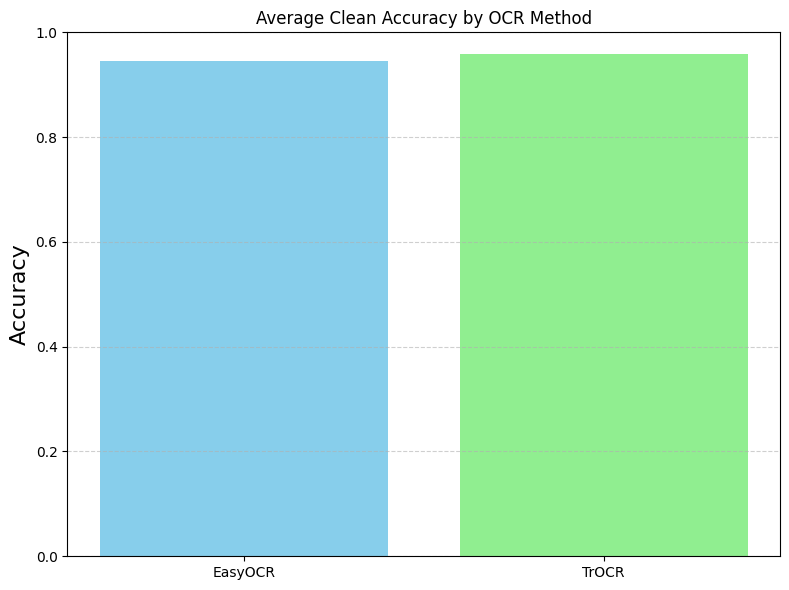

In [13]:
# avg_tesseract = df2['tesseract_acc_clean'].mean() / 100
avg_easyocr = df2['easyocr_acc_clean'].mean() / 100
avg_trocr = df2['trocr_acc_clean'].mean() / 100

# print(avg_easyocr)
# print(avg_tesseract)
# print(avg_trocr)
# Bar plot
plt.figure(figsize=(8, 6))
plt.bar([ 'EasyOCR', 'TrOCR'],
        [avg_easyocr, avg_trocr],
        color=['skyblue', 'lightgreen', 'salmon'])


plt.title('Average Clean Accuracy by OCR Method')
plt.ylabel('Accuracy',fontsize= 16)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

0.7687904479602803
0.37826249836597037
0.9162146666666667


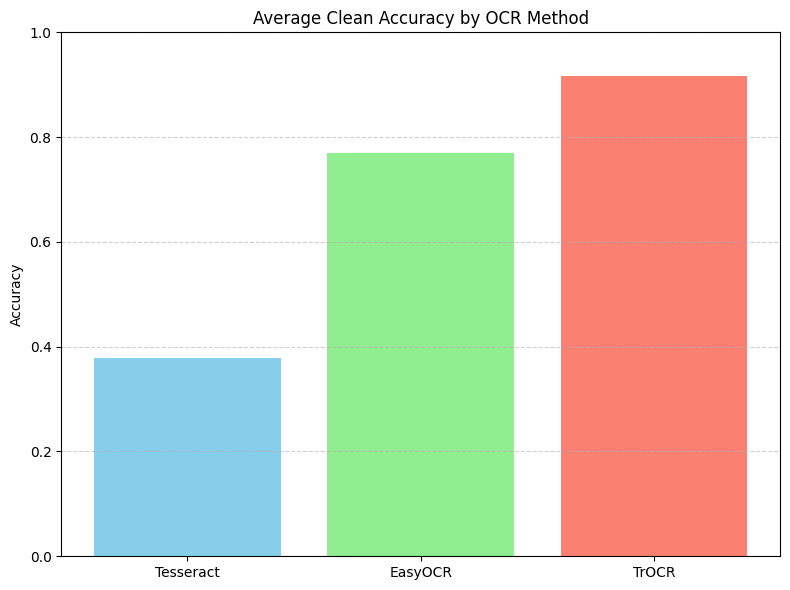

In [14]:
avg_tesseract = df['tesseract_acc_clean'].mean() / 100
avg_easyocr = df['easyocr_acc_clean'].mean() / 100
avg_trocr = df['trocr_acc_clean'].mean() / 100

print(avg_easyocr)
print(avg_tesseract)
print(avg_trocr)
# Bar plot
plt.figure(figsize=(8, 6))
plt.bar(['Tesseract', 'EasyOCR', 'TrOCR'],
        [avg_tesseract, avg_easyocr, avg_trocr],
        color=['skyblue', 'lightgreen', 'salmon'])

plt.title('Average Clean Accuracy by OCR Method')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###Average Accuracy of all ocr for noisy

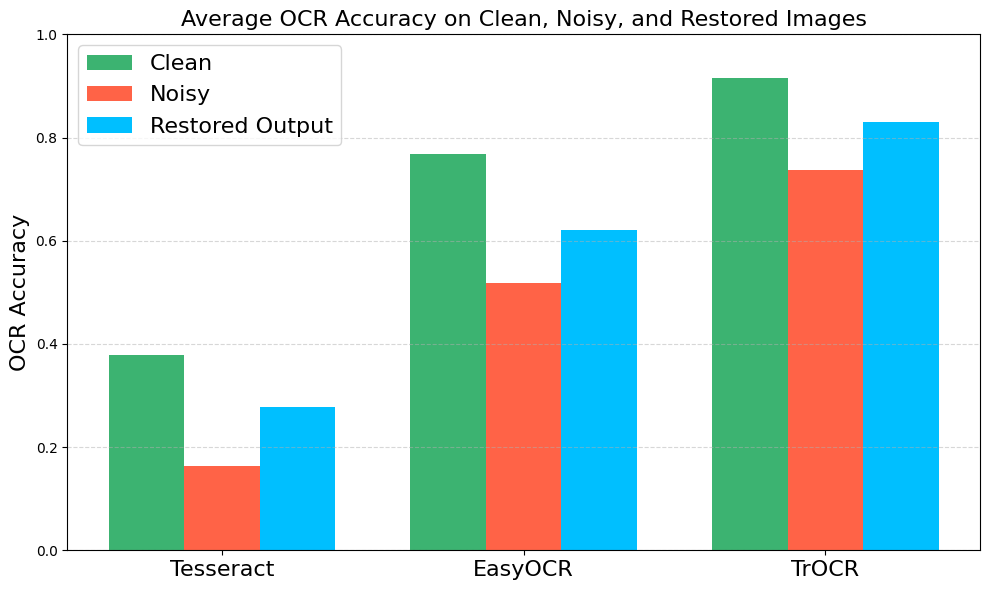

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate average accuracies (scaled to 0–1)
avg_tesseract_clean = df['tesseract_acc_clean'].mean() / 100
avg_tesseract_noisy = df['tesseract_acc_noisy'].mean() / 100
avg_tesseract_output = df['tesseract_acc_output'].mean() / 100

avg_easyocr_clean = df['easyocr_acc_clean'].mean() / 100
avg_easyocr_noisy = df['easyocr_acc_noisy'].mean() / 100
avg_easyocr_output = df['easyocr_acc_output'].mean() / 100

avg_trocr_clean = df['trocr_acc_clean'].mean() / 100
avg_trocr_noisy = df['trocr_acc_noisy'].mean() / 100
avg_trocr_output = df['trocr_acc_output'].mean() / 100

# Data arrangement
labels = ['Tesseract', 'EasyOCR', 'TrOCR']
clean = [avg_tesseract_clean, avg_easyocr_clean, avg_trocr_clean]
noisy = [avg_tesseract_noisy, avg_easyocr_noisy, avg_trocr_noisy]
output = [avg_tesseract_output, avg_easyocr_output, avg_trocr_output]

x = np.arange(len(labels))  # label locations
width = 0.25  # width of the bars

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(x - width, clean, width, label='Clean', color='mediumseagreen')
plt.bar(x, noisy, width, label='Noisy', color='tomato')
plt.bar(x + width, output, width, label='Restored Output', color='deepskyblue')

# Labels and annotations
plt.ylabel('OCR Accuracy',fontsize = 16)
plt.ylim(0, 1)
plt.title('Average OCR Accuracy on Clean, Noisy, and Restored Images' ,fontsize = 16)
plt.xticks(x, labels,fontsize = 16)
plt.legend(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


0.5170703508836934
0.16363192240320007
0.7377209333333333


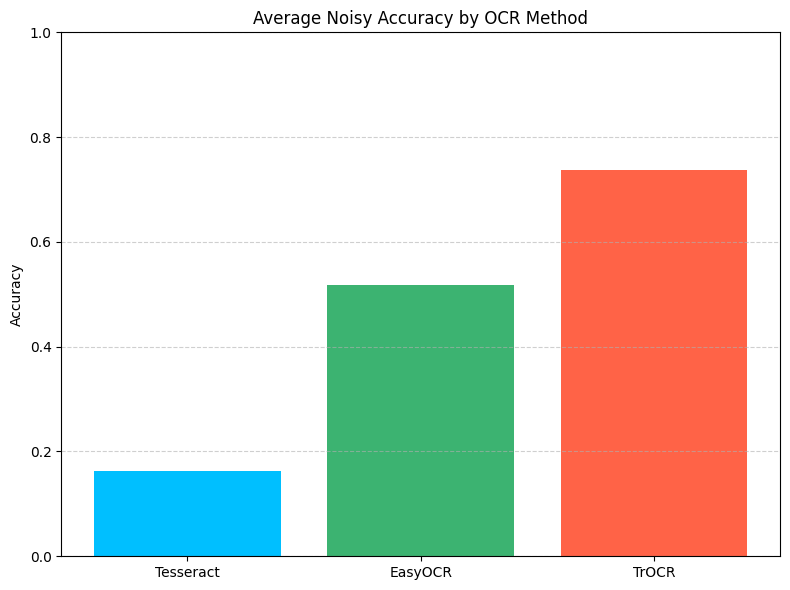

In [18]:
import matplotlib.pyplot as plt

# Calculate average noisy accuracy for each OCR method
avg_tesseract_noisy = df['tesseract_acc_noisy'].mean() /100
avg_easyocr_noisy = df['easyocr_acc_noisy'].mean() /100
avg_trocr_noisy = df['trocr_acc_noisy'].mean() /100

# Bar plot
plt.figure(figsize=(8, 6))
plt.bar(['Tesseract', 'EasyOCR', 'TrOCR'],
        [avg_tesseract_noisy, avg_easyocr_noisy, avg_trocr_noisy],
        color=['deepskyblue', 'mediumseagreen', 'tomato'])
print(avg_easyocr_noisy)
print(avg_tesseract_noisy)
print(avg_trocr_noisy)
plt.title('Average Noisy Accuracy by OCR Method')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


###Average Accuracy of all ocr for output

0.6209581088591648
0.27833305707338757
0.8309884666666666


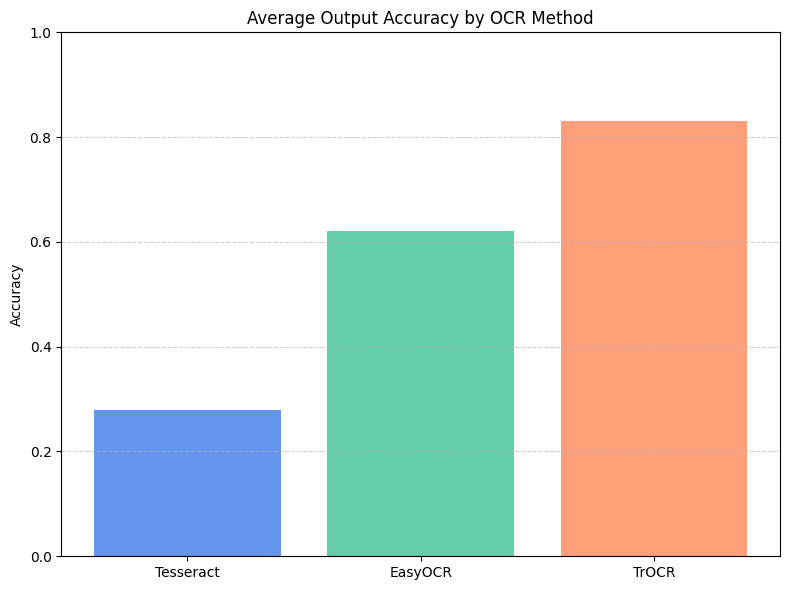

In [19]:
import matplotlib.pyplot as plt

# Calculate average output accuracy for each OCR method
avg_tesseract_output = df['tesseract_acc_output'].mean() /100
avg_easyocr_output = df['easyocr_acc_output'].mean() /100
avg_trocr_output = df['trocr_acc_output'].mean() /100
print(avg_easyocr_output)
print(avg_tesseract_output)
print(avg_trocr_output)
# Bar plot
plt.figure(figsize=(8, 6))
plt.bar(['Tesseract', 'EasyOCR', 'TrOCR'],
        [avg_tesseract_output, avg_easyocr_output, avg_trocr_output],
        color=['cornflowerblue', 'mediumaquamarine', 'lightsalmon'])

plt.title('Average Output Accuracy by OCR Method')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

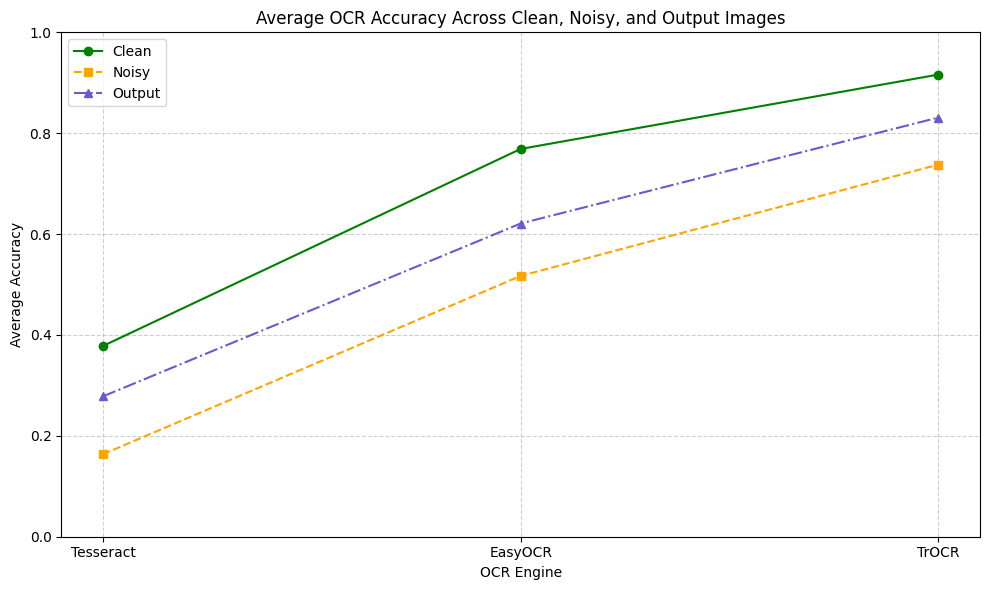

In [22]:
import matplotlib.pyplot as plt

# Define OCR engines
ocr_engines = ['Tesseract', 'EasyOCR', 'TrOCR']

# Calculate average accuracies (scaled to 0–1)
avg_clean_acc = [
    df['tesseract_acc_clean'].mean() / 100,
    df['easyocr_acc_clean'].mean() / 100,
    df['trocr_acc_clean'].mean() / 100
]

avg_noisy_acc = [
    df['tesseract_acc_noisy'].mean() / 100,
    df['easyocr_acc_noisy'].mean() / 100,
    df['trocr_acc_noisy'].mean() / 100
]

avg_output_acc = [
    df['tesseract_acc_output'].mean() / 100,
    df['easyocr_acc_output'].mean() / 100,
    df['trocr_acc_output'].mean() / 100
]

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(ocr_engines, avg_clean_acc, marker='o', linestyle='-', color='green', label='Clean')
plt.plot(ocr_engines, avg_noisy_acc, marker='s', linestyle='--', color='orange', label='Noisy')
plt.plot(ocr_engines, avg_output_acc, marker='^', linestyle='-.', color='slateblue', label='Output')

plt.title('Average OCR Accuracy Across Clean, Noisy, and Output Images')
plt.xlabel('OCR Engine')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### BOX PLOT for all Accuracy for finding outlier

font_style
AnekBangla            40.351471
AnekGujarati          25.438852
AnekGurmukhi           3.768874
AnekMalayalam         40.709005
BSTD                  35.038429
Black                 67.298380
BlackItalic           72.937463
Bold                  67.092466
BoldItalic            81.804520
Copy                  80.328346
DynaPuff              64.681263
ExtraBold             68.230676
ExtraBoldItalic       78.394459
ExtraLight            61.940084
ExtraLightItalic      67.311111
IGNCA                 11.025120
Italic                69.794960
Light                 65.251236
LightItalic           79.130809
Medium                67.357338
MediumItalic          79.780034
NotoSansArabic        42.417019
NotoSansBengali       45.177882
NotoSansDevanagari    54.295187
NotoSansGujarati      32.594317
NotoSansGurmukhi       3.167087
NotoSansMalayalam     57.929383
NotoSansTamil         33.698623
NotoSerifBengali      44.707165
Regular               59.534939
Roboto                79.0433

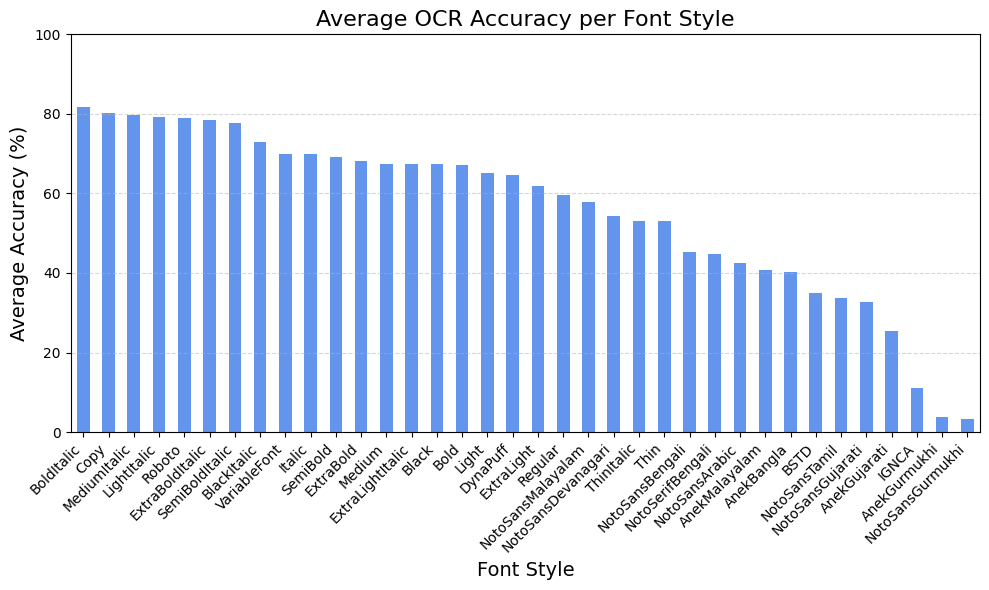

In [25]:
import matplotlib.pyplot as plt

# Safely extract the first part of the font_style (e.g., 'Bold_Italic' → 'Bold')
df['font_style'] = df['font_style'].astype(str).str.split('_').str[0]

# Compute mean OCR output accuracy per font style
avg_font_acc = df.groupby('font_style')[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean()

# Compute average across OCR engines
avg_font_acc['Average Accuracy'] = avg_font_acc.mean(axis=1)

# Optional: print the average accuracies
print(avg_font_acc['Average Accuracy'])

# Plot the bar graph
plt.figure(figsize=(10, 6))
avg_font_acc['Average Accuracy'].sort_values(ascending=False).plot(kind='bar', color='cornflowerblue')

plt.title('Average OCR Accuracy per Font Style', fontsize=16)
plt.ylabel('Average Accuracy (%)', fontsize=14)
plt.xlabel('Font Style', fontsize=14)
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/tmp/ipython-input-26-1210714136.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['font_size'] = df_filtered['font_size'].astype(float)


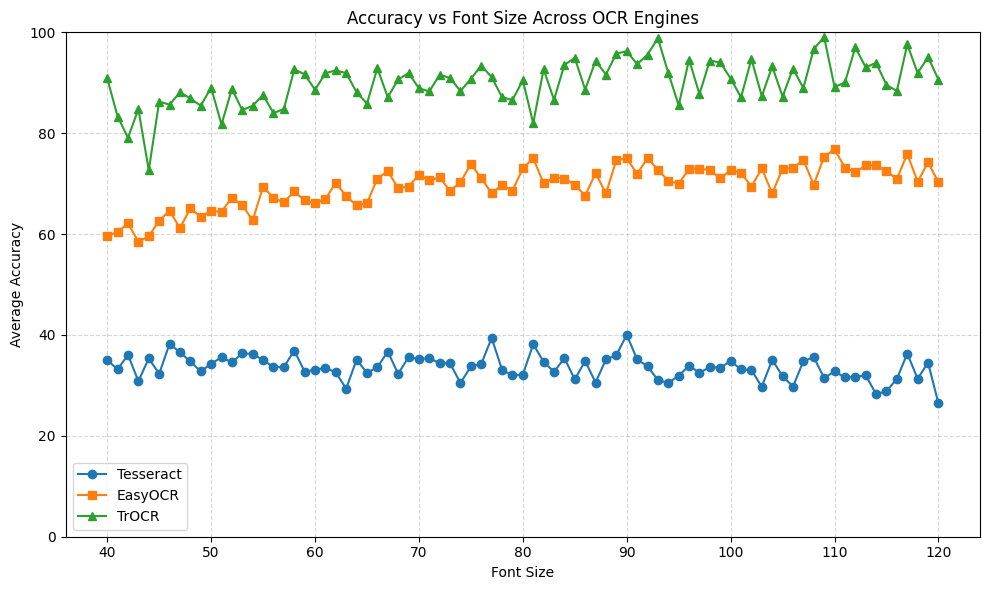

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure font_size is numeric; drop non-numeric like 'bstd'
df_filtered = df[pd.to_numeric(df['font_size'], errors='coerce').notna()]
df_filtered['font_size'] = df_filtered['font_size'].astype(float)

# Group by font_size and compute average accuracy per engine
fontsize_acc = df_filtered.groupby('font_size')[
    ['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']
].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))

# Line Plot
plt.plot(fontsize_acc['font_size'], fontsize_acc['tesseract_acc_output'], marker='o', label='Tesseract')
plt.plot(fontsize_acc['font_size'], fontsize_acc['easyocr_acc_output'], marker='s', label='EasyOCR')
plt.plot(fontsize_acc['font_size'], fontsize_acc['trocr_acc_output'], marker='^', label='TrOCR')

plt.title('Accuracy vs Font Size Across OCR Engines')
plt.xlabel('Font Size')
plt.ylabel('Average Accuracy')
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df_filtered['font_size'].shape

(30000,)

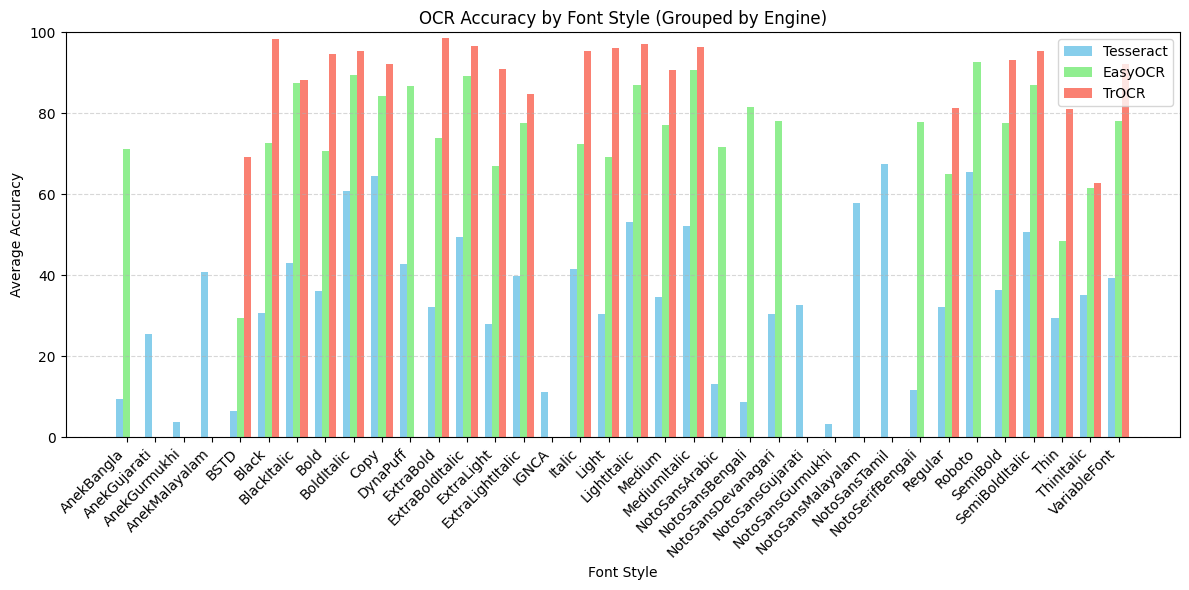

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Group by font_style and compute mean accuracy for each engine
style_acc = df.groupby('font_style')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean()

# Set up positions for grouped bars
styles = style_acc.index.tolist()
x = np.arange(len(styles))  # label locations
width = 0.25  # width of each bar

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width, style_acc['tesseract_acc_output'], width, label='Tesseract', color='skyblue')
plt.bar(x,         style_acc['easyocr_acc_output'], width, label='EasyOCR', color='lightgreen')
plt.bar(x + width, style_acc['trocr_acc_output'], width, label='TrOCR', color='salmon')

# Styling
plt.xticks(x, styles, rotation=45, ha='right')
plt.xlabel('Font Style')
plt.ylabel('Average Accuracy')
plt.title('OCR Accuracy by Font Style (Grouped by Engine)')
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

not useful

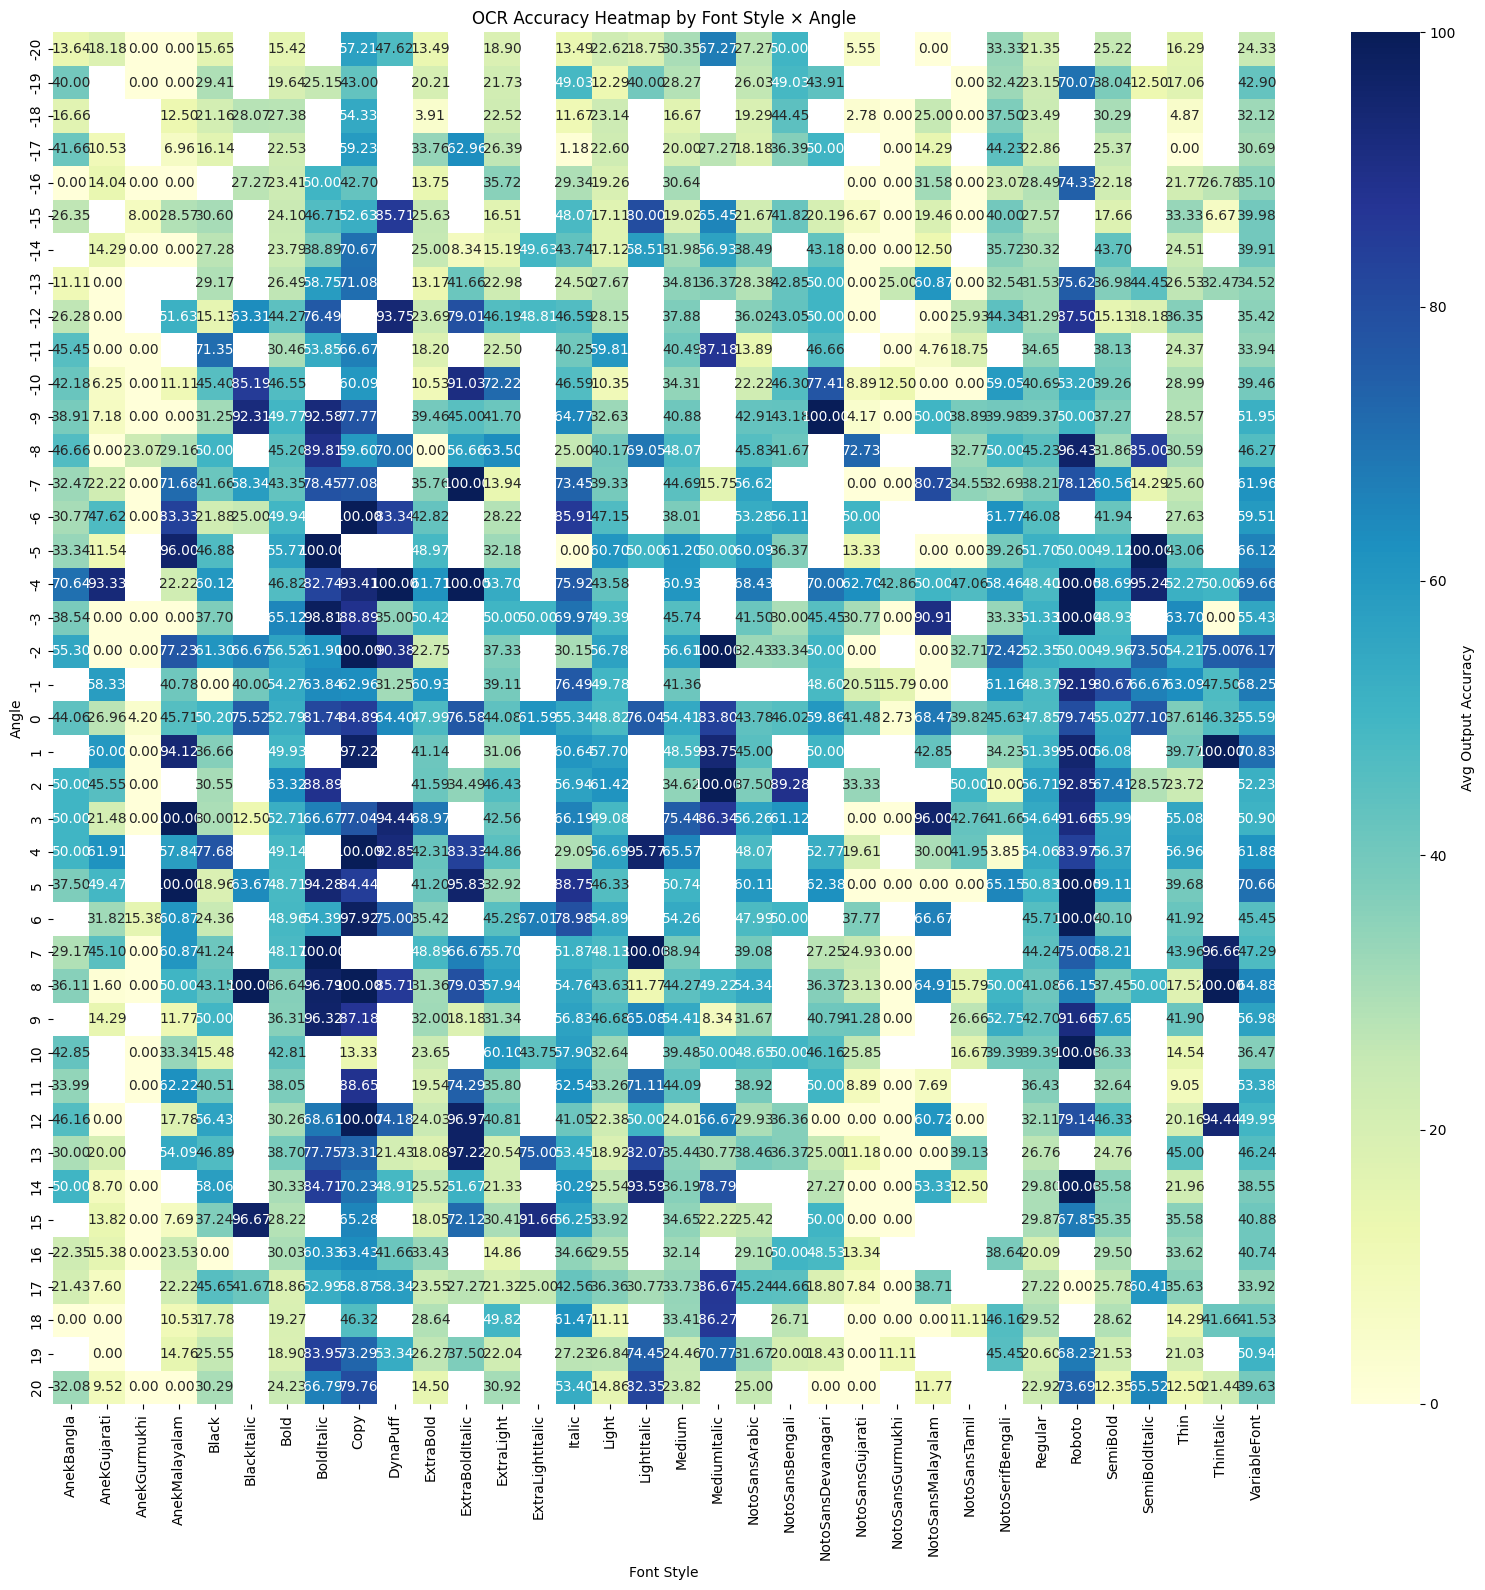

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate average output accuracy
df['avg_output_acc'] = df[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean(axis=1)

# Step 2: Clean angle column (remove non-numeric, like 'bstd')
df_cleaned = df.copy()
df_cleaned['angle'] = pd.to_numeric(df_cleaned['angle'], errors='coerce')
df_cleaned = df_cleaned.dropna(subset=['angle'])
df_cleaned['angle'] = df_cleaned['angle'].astype(int)  # Optional: convert to integer degrees

# Step 3: Create pivot table
heatmap_df = df_cleaned.pivot_table(
    index='angle',
    columns='font_style',
    values='avg_output_acc',
    aggfunc='mean'
)

# Step 4: Plot the heatmap
plt.figure(figsize=(16, 16))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap='YlGnBu', cbar_kws={'label': 'Avg Output Accuracy'})

plt.title('OCR Accuracy Heatmap by Font Style × Angle')
plt.xlabel('Font Style')
plt.ylabel('Angle')
plt.tight_layout()
plt.show()

# Optional: view processed pivot table


?

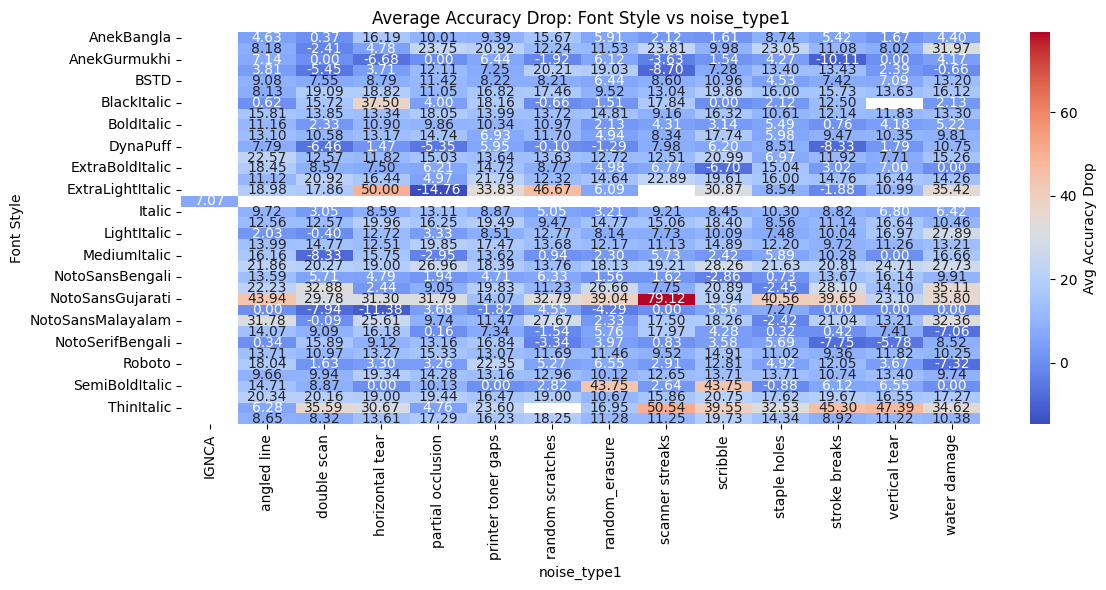

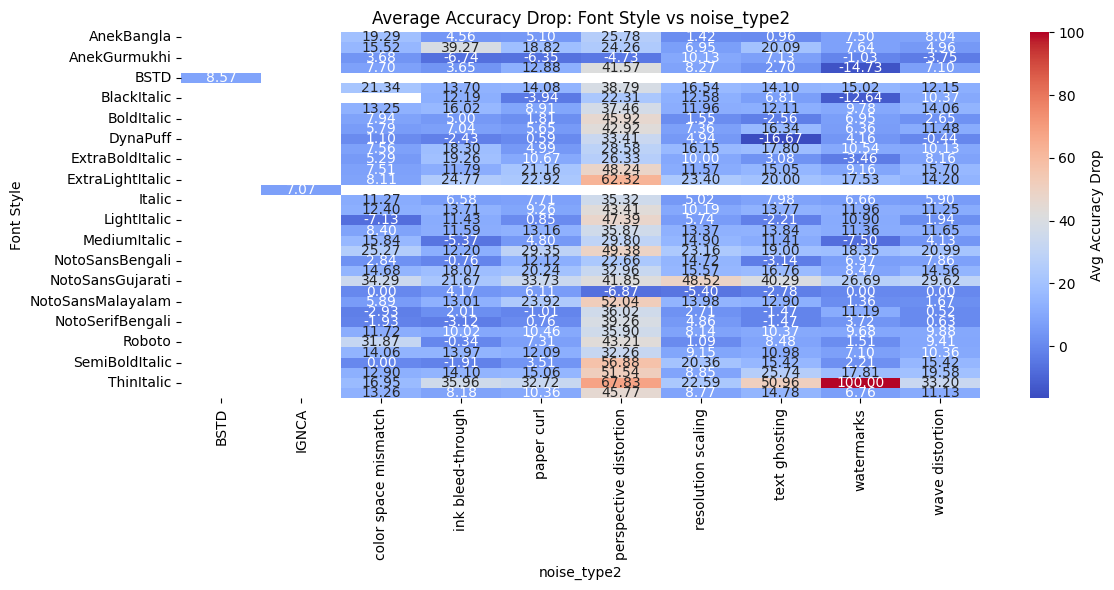

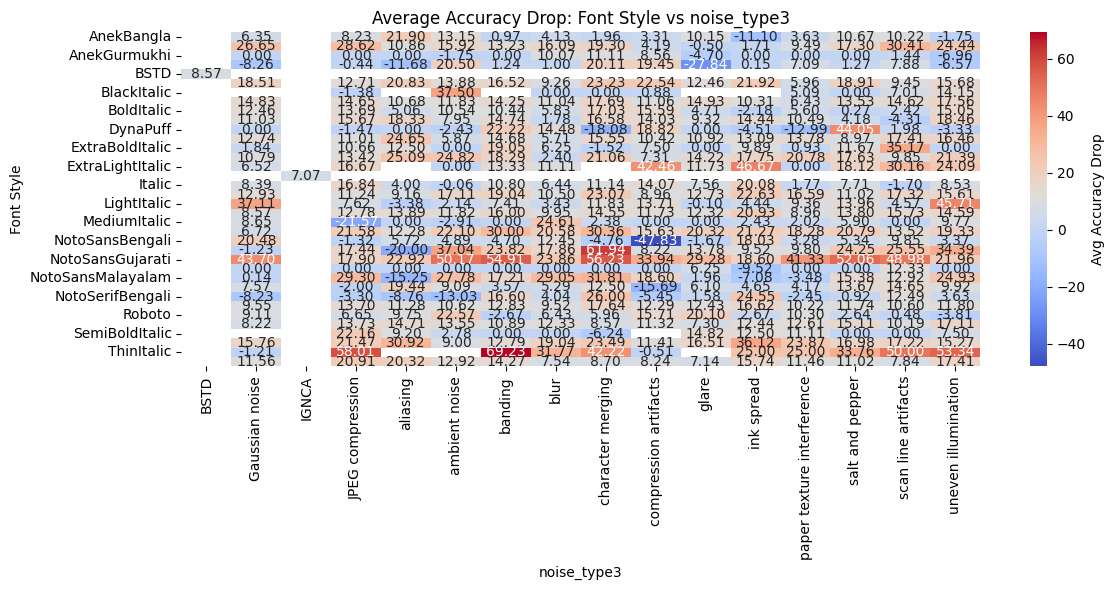

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Compute individual accuracy drops
df['tesseract_drop'] = df['tesseract_acc_clean'] - df['tesseract_acc_output']
df['easyocr_drop'] = df['easyocr_acc_clean'] - df['easyocr_acc_output']
df['trocr_drop'] = df['trocr_acc_clean'] - df['trocr_acc_output']

# Step 2: Compute average drop across all OCR engines
df['avg_drop'] = df[['tesseract_drop', 'easyocr_drop', 'trocr_drop']].mean(axis=1)

# Step 3: Plot heatmaps for each noise type
for noise_type in ['noise_type1', 'noise_type2', 'noise_type3']:
    plt.figure(figsize=(12, 6))
    pivot = df.pivot_table(values='avg_drop', index='font_style', columns=noise_type, aggfunc='mean')
    sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Avg Accuracy Drop'})
    plt.title(f"Average Accuracy Drop: Font Style vs {noise_type}")
    plt.xlabel(noise_type)
    plt.ylabel("Font Style")
    plt.tight_layout()
    plt.show()


accuracy on the basis of text_color
one more visual which text color and bgclr has lowest acc

In [31]:
df['text_color'].value_counts().shape

(49,)

49


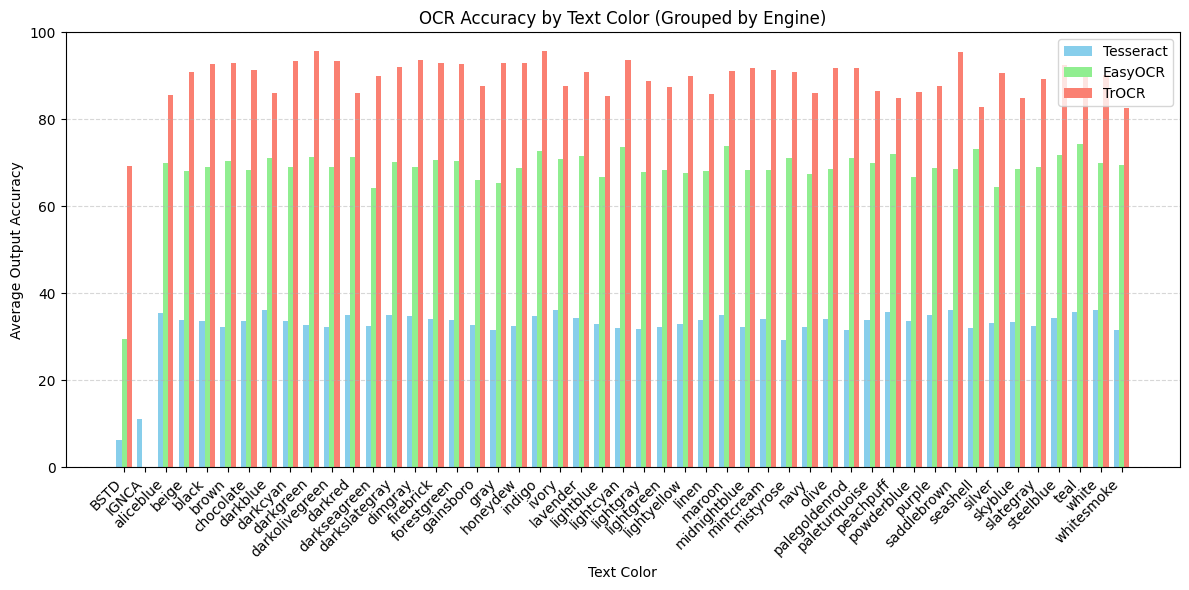

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Group by text_color and calculate mean accuracy for each OCR engine
color_acc = df.groupby('text_color')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean()

# Plotting setup
colors = color_acc.index.tolist()
x = np.arange(len(colors))  # the label locations
width = 0.25  # width of the bars
print(len(colors))
# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width, color_acc['tesseract_acc_output'], width, label='Tesseract', color='skyblue')
plt.bar(x,         color_acc['easyocr_acc_output'], width, label='EasyOCR', color='lightgreen')
plt.bar(x + width, color_acc['trocr_acc_output'], width, label='TrOCR', color='salmon')

plt.xlabel('Text Color')
plt.ylabel('Average Output Accuracy')
plt.title('OCR Accuracy by Text Color (Grouped by Engine)')
plt.xticks(x, colors, rotation=45, ha='right')
plt.ylim(0, 100)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


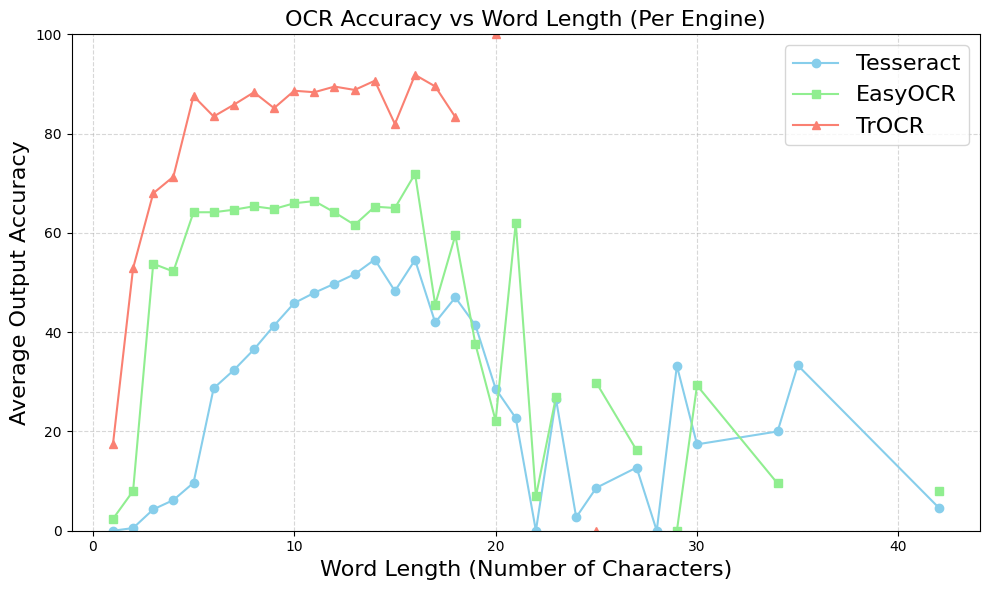

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute word length
df['word_length'] = df['word'].astype(str).apply(len)

# Group by word length and calculate average accuracies
length_acc = df.groupby('word_length')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(length_acc['word_length'], length_acc['tesseract_acc_output'], marker='o', label='Tesseract', color='skyblue')
plt.plot(length_acc['word_length'], length_acc['easyocr_acc_output'], marker='s', label='EasyOCR', color='lightgreen')
plt.plot(length_acc['word_length'], length_acc['trocr_acc_output'], marker='^', label='TrOCR', color='salmon')

plt.title('OCR Accuracy vs Word Length (Per Engine)',fontsize = 16)
plt.xlabel('Word Length (Number of Characters)',fontsize = 16)
plt.ylabel('Average Output Accuracy',fontsize = 16)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize = 16)
plt.tight_layout()
plt.show()

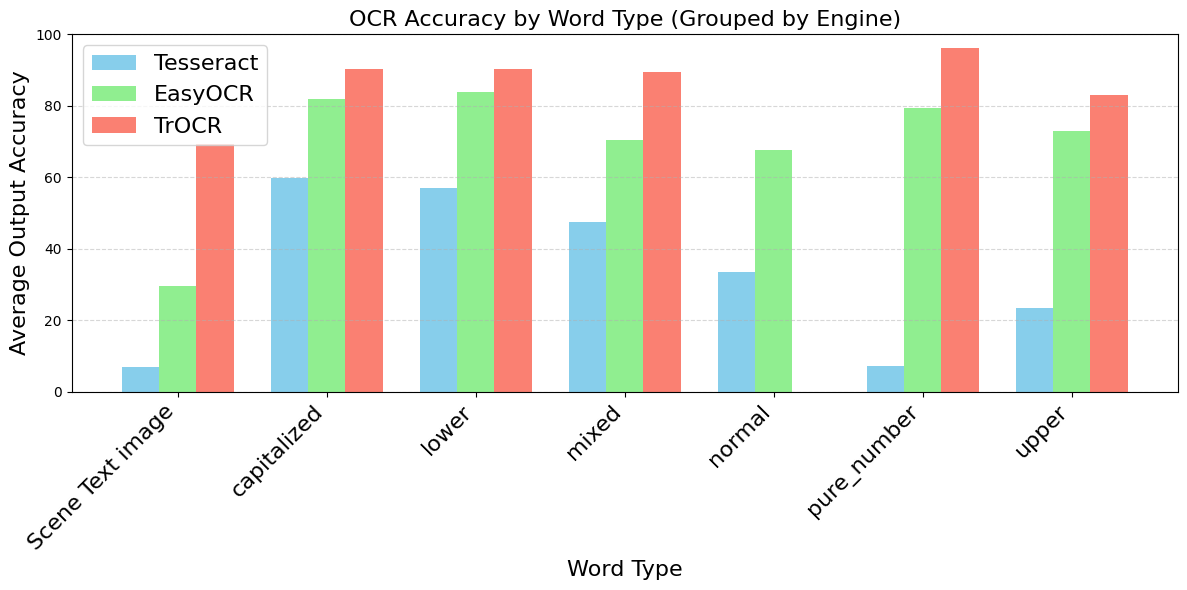

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Group by word_type and calculate average output accuracy for each OCR engine
type_acc = df.groupby('word_type')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean()

# Setup
types = type_acc.index.tolist()
x = np.arange(len(types))  # label positions
width = 0.25  # width of each bar

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width, type_acc['tesseract_acc_output'], width, label='Tesseract', color='skyblue')
plt.bar(x,         type_acc['easyocr_acc_output'], width, label='EasyOCR', color='lightgreen')
plt.bar(x + width, type_acc['trocr_acc_output'], width, label='TrOCR', color='salmon')

# Styling
plt.xlabel('Word Type',fontsize = 16)
plt.ylabel('Average Output Accuracy',fontsize = 16)
plt.title('OCR Accuracy by Word Type (Grouped by Engine)',fontsize = 16)
plt.xticks(x, types, rotation=45, ha='right',fontsize = 16)
plt.ylim(0, 100)
plt.legend(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


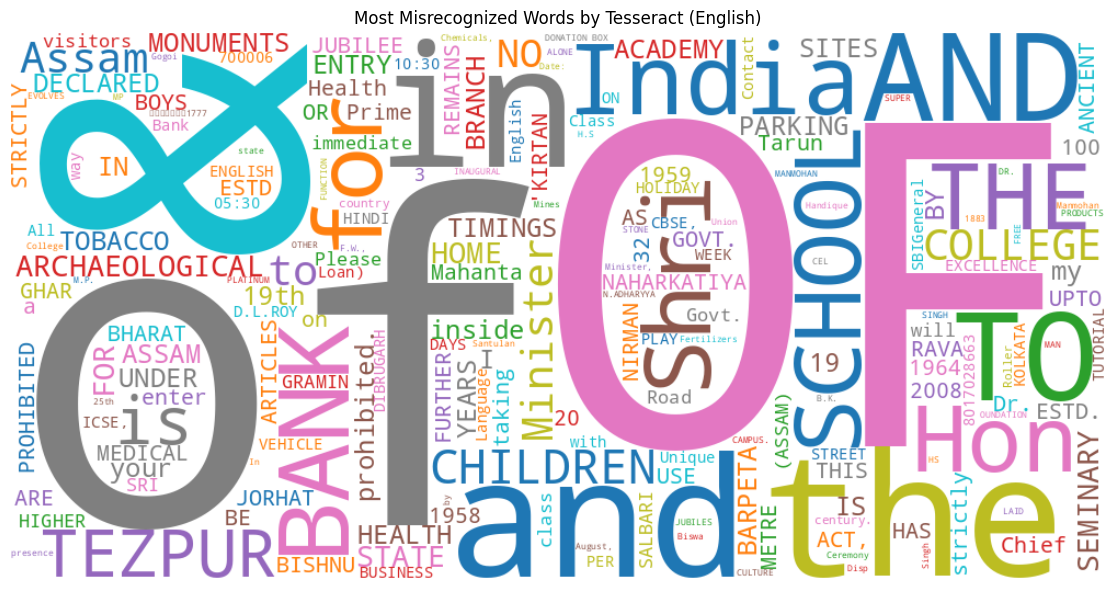

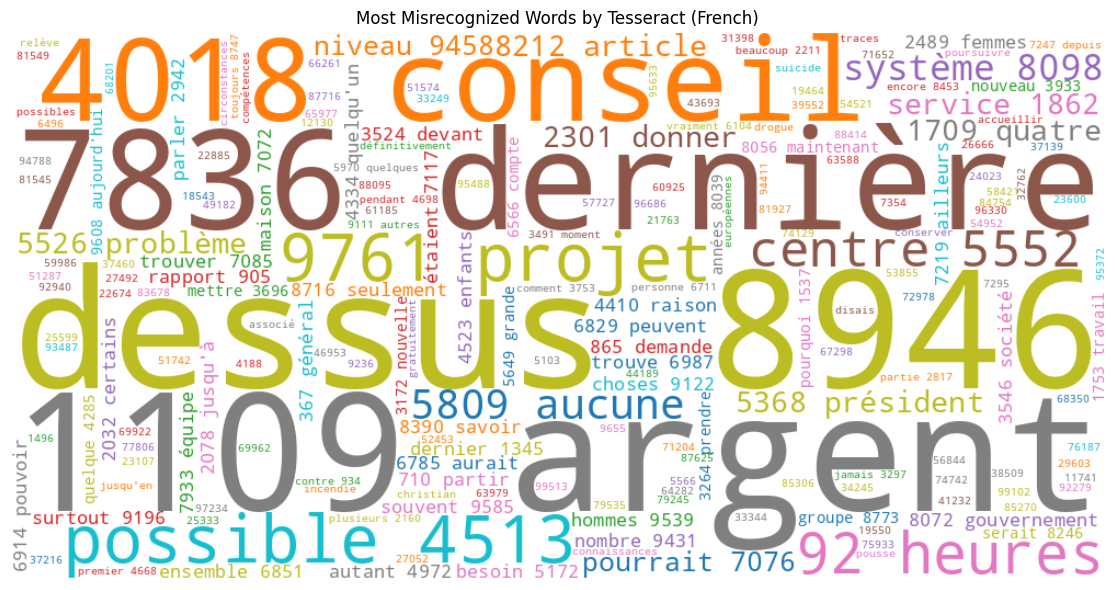

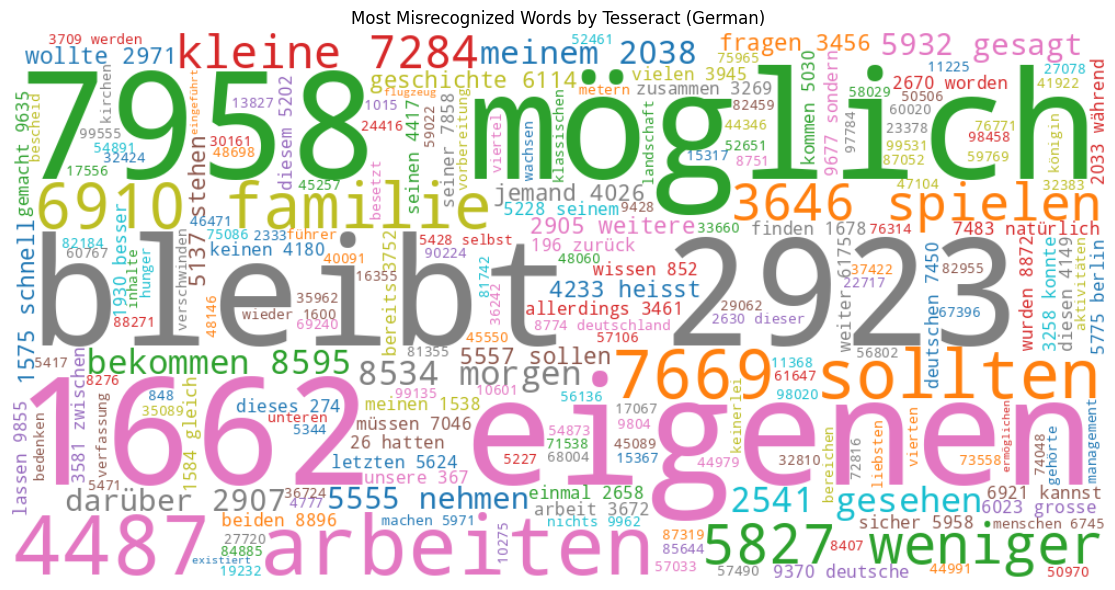

In [49]:
import pandas as pd
import editdistance
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate word cloud for a specific language
def generate_wordcloud_for_language(language, df):
    # Filter DataFrame
    df_lang = df[df['language'] == language].copy()

    # Compute edit distance between ground truth and Tesseract output
    df_lang['edit_dist_tesseract'] = df_lang.apply(
        lambda row: editdistance.eval(str(row['word']), str(row['tesseract_output'])), axis=1
    )

    # Filter mismatches
    mistakes = df_lang[df_lang['edit_dist_tesseract'] > 0]

    # Count word frequency
    word_freq = Counter(mistakes['word'].astype(str))

    if not word_freq:
        print(f"No mismatches found for {language}.")
        return

    # Generate word cloud
    wordcloud = WordCloud(
        width=1000, height=500,
        background_color='white',
        colormap='tab10'
    ).generate_from_frequencies(word_freq)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Most Misrecognized Words by Tesseract ({language})')
    plt.tight_layout()
    plt.show()

# Generate word clouds for each language
for lang in ['English', 'French', 'German']:
    generate_wordcloud_for_language(lang, df)


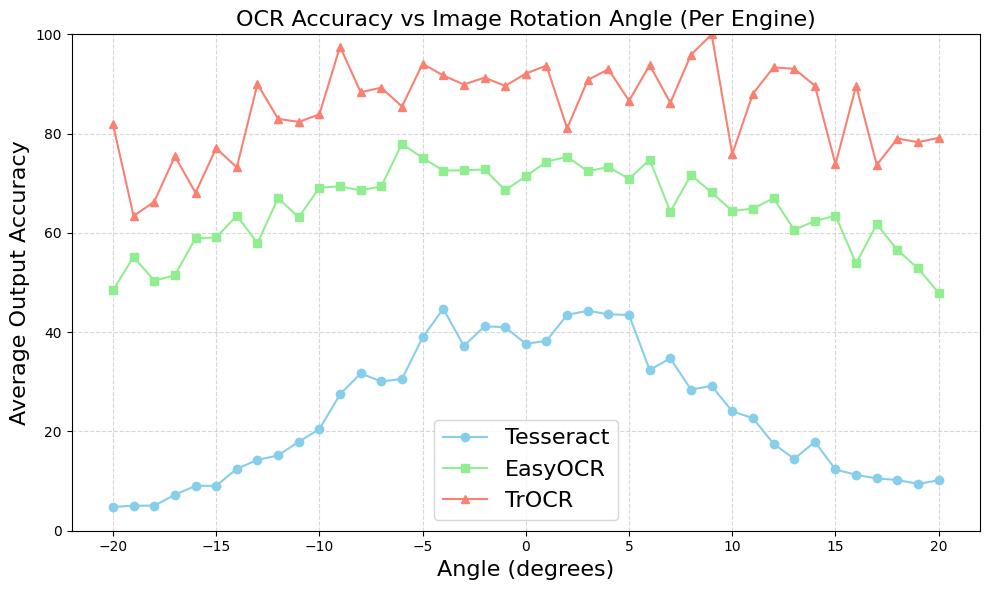

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter out non-numeric angles (e.g., 'bstd')
df_numeric_angles = df[pd.to_numeric(df['angle'], errors='coerce').notna()].copy()
df_numeric_angles['angle'] = df_numeric_angles['angle'].astype(float)

# Group by angle and calculate average accuracies
angle_acc = df_numeric_angles.groupby('angle')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(angle_acc['angle'], angle_acc['tesseract_acc_output'], marker='o', label='Tesseract', color='skyblue')
plt.plot(angle_acc['angle'], angle_acc['easyocr_acc_output'], marker='s', label='EasyOCR', color='lightgreen')
plt.plot(angle_acc['angle'], angle_acc['trocr_acc_output'], marker='^', label='TrOCR', color='salmon')

plt.title('OCR Accuracy vs Image Rotation Angle (Per Engine)',fontsize = 16)
plt.xlabel('Angle (degrees)',fontsize = 16)
plt.ylabel('Average Output Accuracy',fontsize = 16)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize = 16)
plt.tight_layout()
plt.show()


/tmp/ipython-input-60-133511525.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=combined_melted, x='language', y='Accuracy', hue='Group', palette='Set2', ci=None)


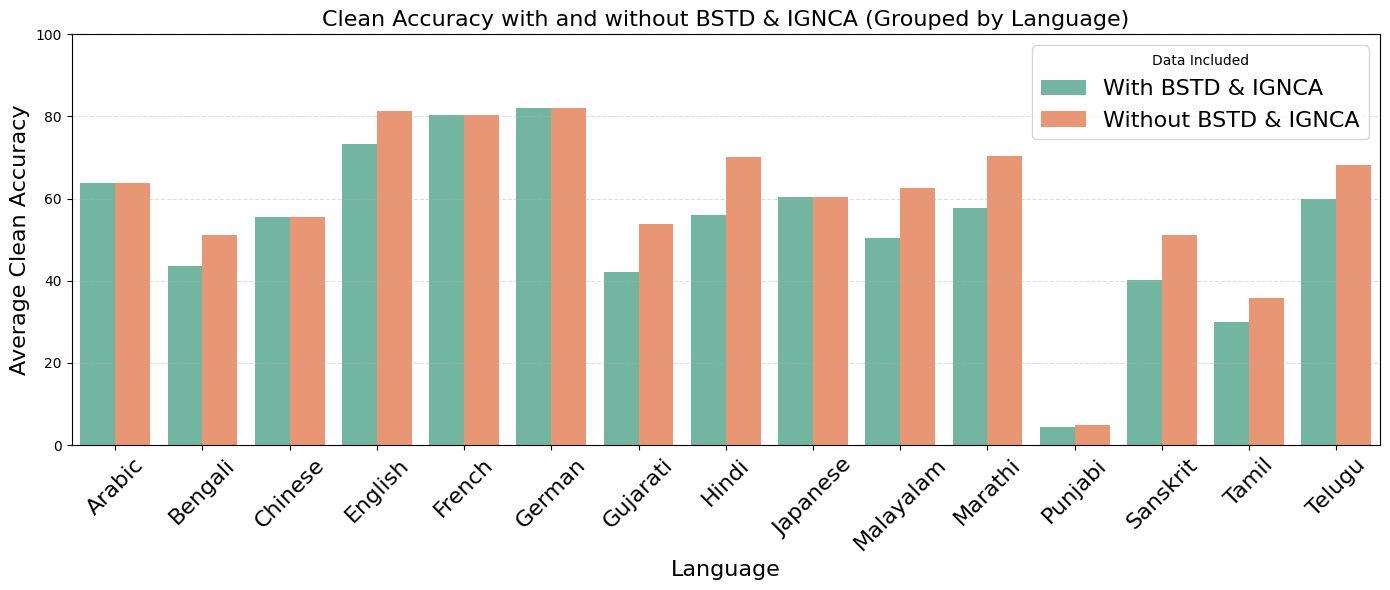

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Compute accuracy per language WITH BSTD and IGNCA
with_all = df.groupby('language')[[
    'tesseract_acc_clean', 'easyocr_acc_clean', 'trocr_acc_clean'
]].mean().reset_index()
with_all['Group'] = 'With BSTD & IGNCA'

# Step 2: Compute accuracy per language WITHOUT BSTD and IGNCA
filtered_df = df[~df['word_type'].isin(['Scene Text image'])]
without = filtered_df.groupby('language')[[
    'tesseract_acc_clean', 'easyocr_acc_clean', 'trocr_acc_clean'
]].mean().reset_index()
without['Group'] = 'Without BSTD & IGNCA'

# Step 3: Combine for plotting
combined = pd.concat([with_all, without])
combined_melted = pd.melt(combined, id_vars=['language', 'Group'],
                          value_vars=['tesseract_acc_clean', 'easyocr_acc_clean', 'trocr_acc_clean'],
                          var_name='OCR Engine', value_name='Accuracy')

# Optional: Clean up OCR Engine names
combined_melted['OCR Engine'] = combined_melted['OCR Engine'].str.replace('_acc_clean', '').str.title()

# Step 4: Plot grouped bar chart
plt.figure(figsize=(14, 6))
import seaborn as sns
sns.barplot(data=combined_melted, x='language', y='Accuracy', hue='Group', palette='Set2', ci=None)

plt.title('Clean Accuracy with and without BSTD & IGNCA (Grouped by Language)',fontsize = 16)
plt.xlabel('Language',fontsize = 16)
plt.ylabel('Average Clean Accuracy',fontsize = 16)
plt.ylim(0, 100)
plt.xticks(rotation=45,fontsize = 16)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Data Included',fontsize = 16)
plt.tight_layout()
plt.show()

heat map for bgclr and textclr


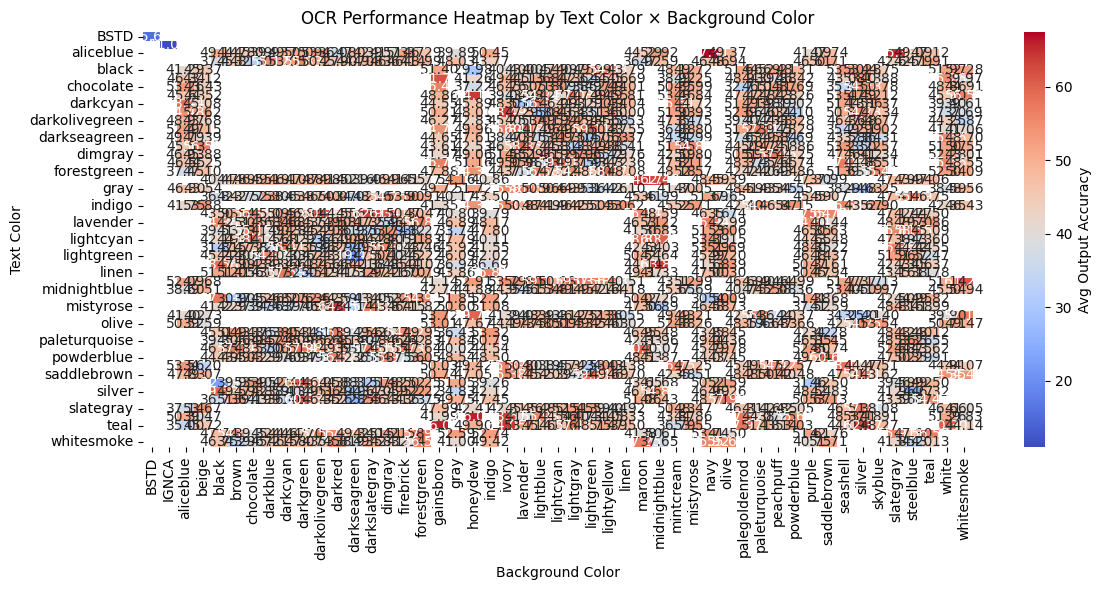

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean of output accuracies across all OCR engines
df['avg_output_acc'] = df[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean(axis=1)

# Create pivot table: rows = text_color, columns = background_color
heatmap_data = df.pivot_table(
    index='text_color',
    columns='background_color',
    values='avg_output_acc',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Avg Output Accuracy'})

plt.title('OCR Performance Heatmap by Text Color × Background Color')
plt.xlabel('Background Color')
plt.ylabel('Text Color')
plt.tight_layout()
plt.show()


accuracy as per language

In [ ]:
df.shape

(36890, 38)

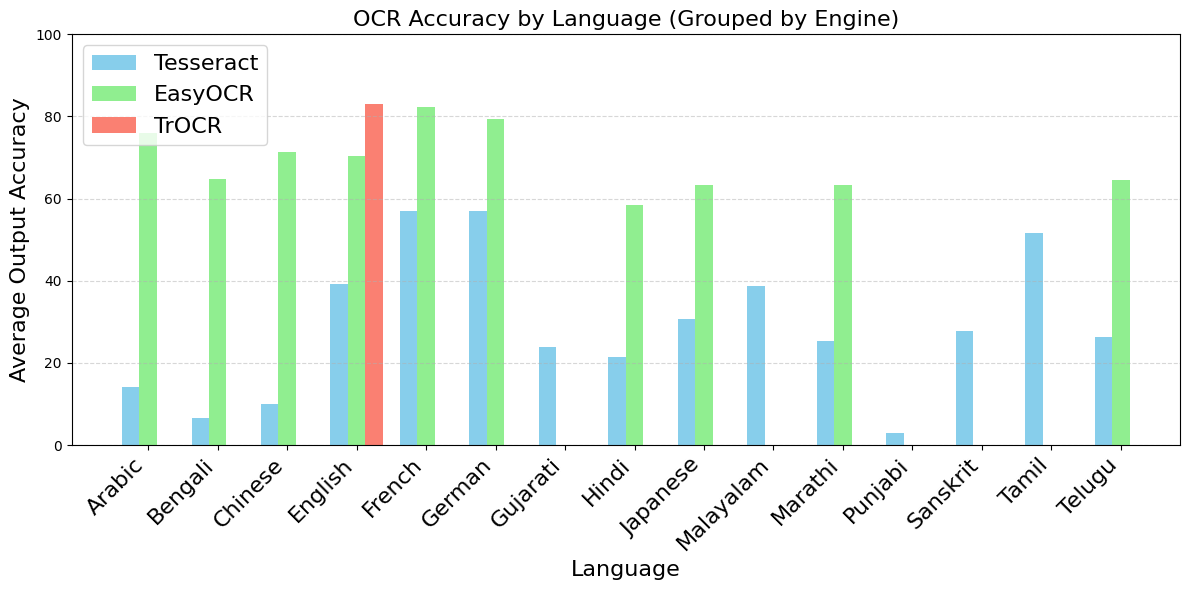

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Group by language_x and calculate mean output accuracy per engine
lang_acc = df.groupby('language')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean()

# Setup
languages = lang_acc.index.tolist()
x = np.arange(len(languages))  # label positions
width = 0.25  # bar width

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width, lang_acc['tesseract_acc_output'], width, label='Tesseract', color='skyblue')
plt.bar(x,         lang_acc['easyocr_acc_output'], width, label='EasyOCR', color='lightgreen')
plt.bar(x + width, lang_acc['trocr_acc_output'], width, label='TrOCR', color='salmon')

# Styling
plt.xlabel('Language',fontsize = 16)
plt.ylabel('Average Output Accuracy',fontsize = 16)
plt.title('OCR Accuracy by Language (Grouped by Engine)',fontsize = 16)
plt.xticks(x, languages, rotation=45, ha='right',fontsize = 16)
plt.ylim(0, 100,)
plt.legend(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

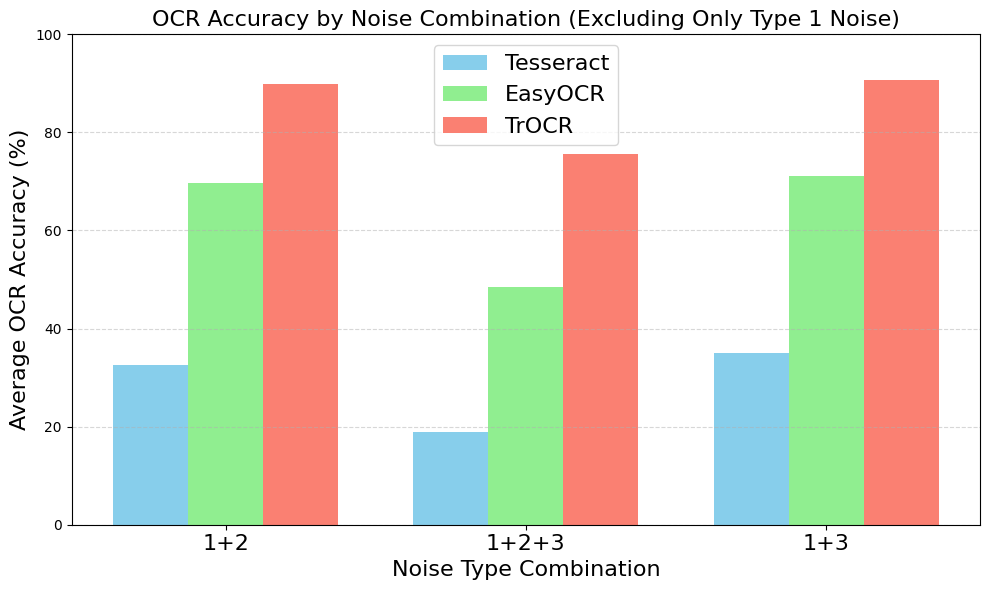

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ❌ Remove rows with only type 1 noise
df_filtered = df[~((df['noise_type1'] != "") & (df['noise_type2'] == "") & (df['noise_type3'] == ""))].copy()

# ✅ Create a new column representing noise combination
def get_noise_comb(row):
    active = []
    if row['noise_type1'] != "":
        active.append("1")
    if row['noise_type2'] != "":
        active.append("2")
    if row['noise_type3'] != "":
        active.append("3")
    return "+".join(active)

df_filtered['noise_combination'] = df_filtered.apply(get_noise_comb, axis=1)

# ✅ Group by noise combination and compute average OCR accuracies
grouped = df_filtered.groupby('noise_combination')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean().reset_index()

# ✅ Plot
plt.figure(figsize=(10, 6))
bar_width = 0.25
x = range(len(grouped))

plt.bar([i - bar_width for i in x], grouped['tesseract_acc_output'], width=bar_width, label='Tesseract', color='skyblue')
plt.bar(x, grouped['easyocr_acc_output'], width=bar_width, label='EasyOCR', color='lightgreen')
plt.bar([i + bar_width for i in x], grouped['trocr_acc_output'], width=bar_width, label='TrOCR', color='salmon')

plt.xticks(ticks=x, labels=grouped['noise_combination'],fontsize = 16)
plt.xlabel("Noise Type Combination",fontsize = 16)
plt.ylabel("Average OCR Accuracy (%)",fontsize = 16)
plt.title("OCR Accuracy by Noise Combination (Excluding Only Type 1 Noise)",fontsize = 16)
plt.ylim(0, 100)
plt.legend(fontsize = 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

accuracy as per wordtype

heatmap for accuracy and lang

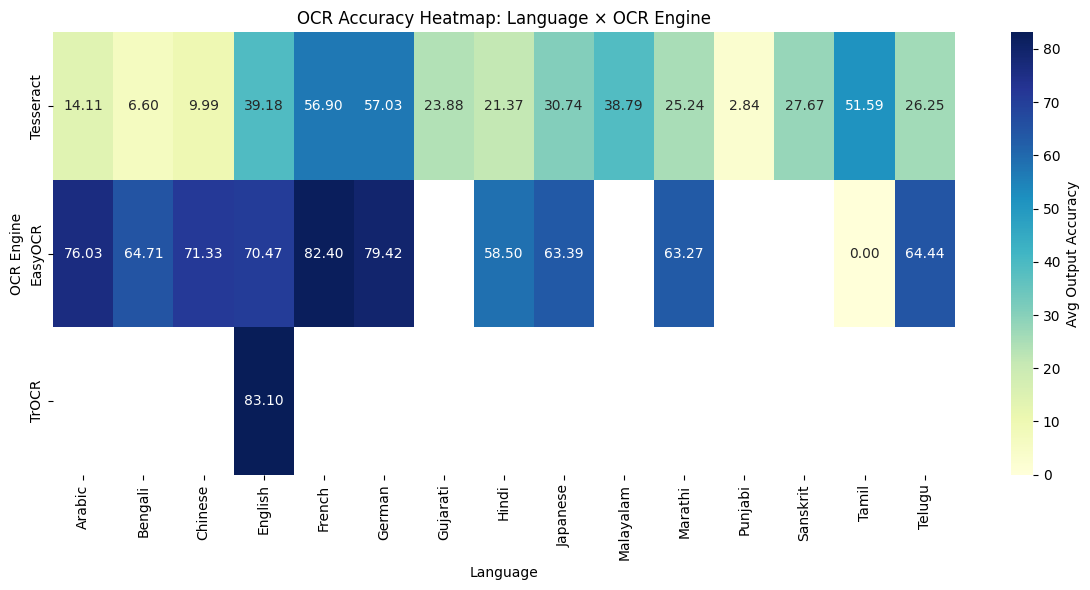

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare average output accuracy per language and engine
lang_engine_acc = df.groupby('language')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean()

# Rename columns for heatmap clarity
lang_engine_acc.columns = ['Tesseract', 'EasyOCR', 'TrOCR']

# Transpose for heatmap layout: rows = OCR engines, columns = languages
heatmap_data = lang_engine_acc.T

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu', cbar_kws={'label': 'Avg Output Accuracy'})

plt.title('OCR Accuracy Heatmap: Language × OCR Engine')
plt.xlabel('Language')
plt.ylabel('OCR Engine')
plt.tight_layout()
plt.show()


Which noise decrease the accuracy more

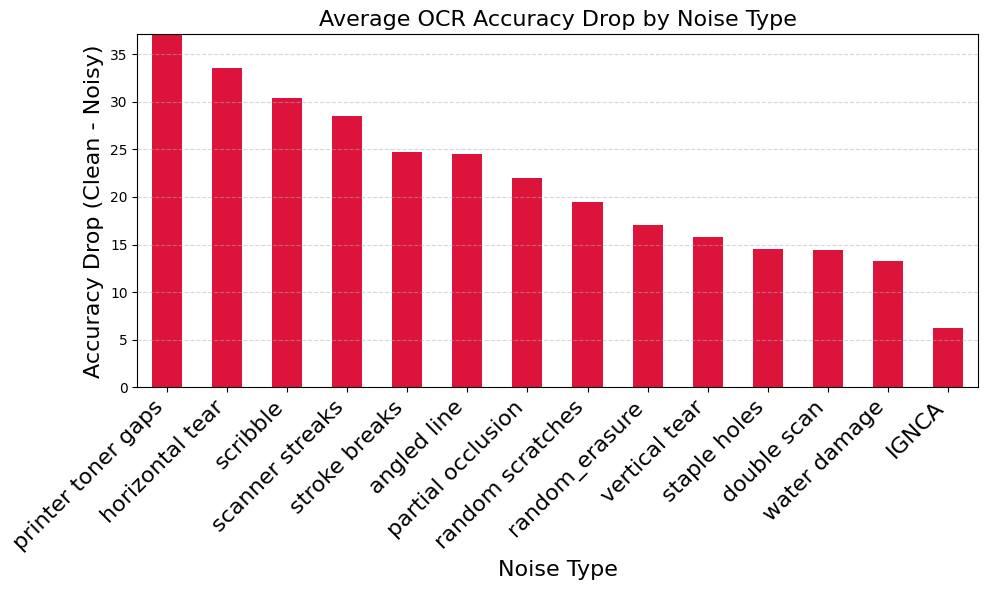

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate per-engine drop
df['tesseract_drop'] = df['tesseract_acc_clean'] - df['tesseract_acc_noisy']
df['easyocr_drop'] = df['easyocr_acc_clean'] - df['easyocr_acc_noisy']
df['trocr_drop'] = df['trocr_acc_clean'] - df['trocr_acc_noisy']

# Average drop across engines
df['avg_drop'] = df[['tesseract_drop', 'easyocr_drop', 'trocr_drop']].mean(axis=1)

# Group by noise_type1_y and calculate mean drop
drop_by_noise = df.groupby('noise_type1')['avg_drop'].mean().sort_values(ascending=False)

# Bar plot
plt.figure(figsize=(10, 6))
drop_by_noise.plot(kind='bar', color='crimson')

plt.title('Average OCR Accuracy Drop by Noise Type',fontsize= 16)
plt.xlabel('Noise Type',fontsize= 16)
plt.ylabel('Accuracy Drop (Clean - Noisy)',fontsize= 16)
plt.ylim(0, drop_by_noise.max() + 0.05)
plt.xticks(rotation=45, ha='right',fontsize= 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


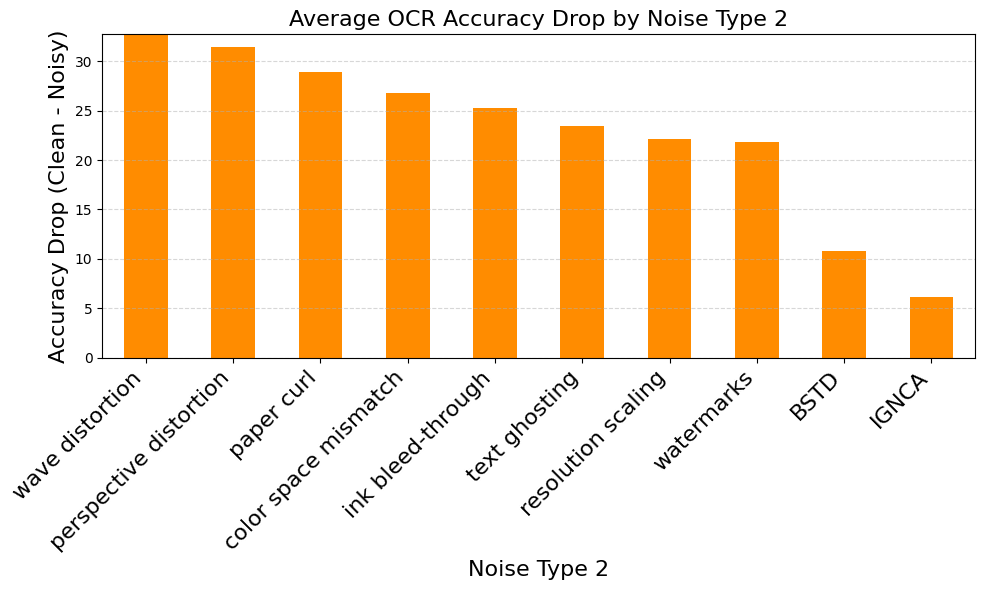

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure drops are calculated
df['tesseract_drop'] = df['tesseract_acc_clean'] - df['tesseract_acc_noisy']
df['easyocr_drop'] = df['easyocr_acc_clean'] - df['easyocr_acc_noisy']
df['trocr_drop'] = df['trocr_acc_clean'] - df['trocr_acc_noisy']

# Average drop across engines
df['avg_drop'] = df[['tesseract_drop', 'easyocr_drop', 'trocr_drop']].mean(axis=1)

# Group by noise_type2_y and calculate mean drop
drop_by_noise2 = df.groupby('noise_type2')['avg_drop'].mean().sort_values(ascending=False)

# Bar plot
plt.figure(figsize=(10, 6))
drop_by_noise2.plot(kind='bar', color='darkorange')

plt.title('Average OCR Accuracy Drop by Noise Type 2',fontsize= 16)
plt.xlabel('Noise Type 2',fontsize= 16)
plt.ylabel('Accuracy Drop (Clean - Noisy)',fontsize= 16)
plt.ylim(0, drop_by_noise2.max() + 0.05)
plt.xticks(rotation=45, ha='right',fontsize= 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

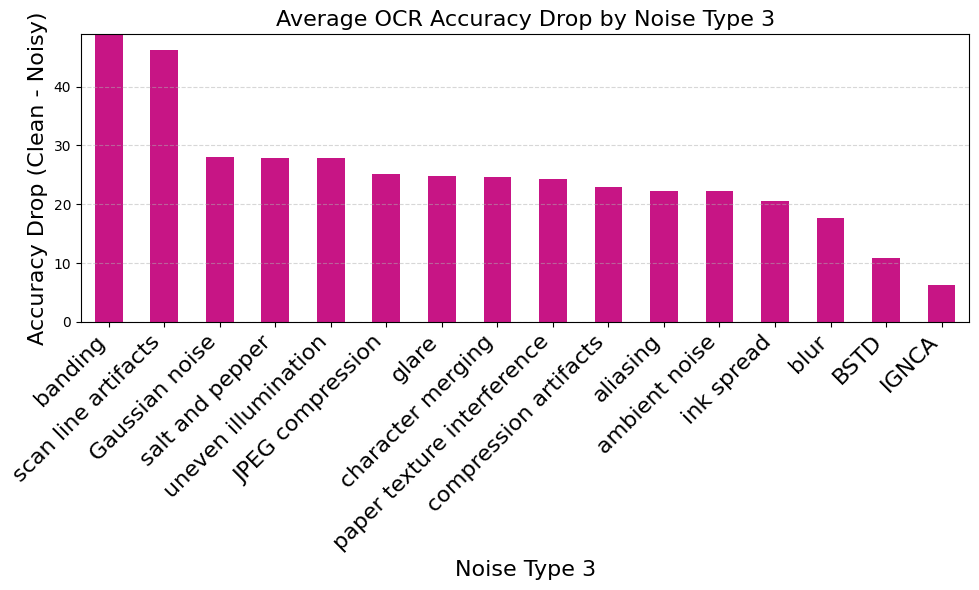

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate per-engine drop (if not already calculated)
df['tesseract_drop'] = df['tesseract_acc_clean'] - df['tesseract_acc_noisy']
df['easyocr_drop'] = df['easyocr_acc_clean'] - df['easyocr_acc_noisy']
df['trocr_drop'] = df['trocr_acc_clean'] - df['trocr_acc_noisy']

# Average drop across all engines
df['avg_drop'] = df[['tesseract_drop', 'easyocr_drop', 'trocr_drop']].mean(axis=1)

# Group by noise_type3_y and compute mean drop
drop_by_noise3 = df.groupby('noise_type3')['avg_drop'].mean().sort_values(ascending=False)

# Bar plot
plt.figure(figsize=(10, 6))
drop_by_noise3.plot(kind='bar', color='mediumvioletred')

plt.title('Average OCR Accuracy Drop by Noise Type 3',fontsize= 16)
plt.xlabel('Noise Type 3',fontsize= 16)
plt.ylabel('Accuracy Drop (Clean - Noisy)',fontsize= 16)
plt.ylim(0, drop_by_noise3.max() + 0.05)
plt.xticks(rotation=45, ha='right',fontsize= 16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [43]:
# Count for each model where output accuracy is greater than noisy accuracy
tesseract_better = (df['tesseract_acc_output'] <= df['tesseract_acc_noisy']).sum()
easyocr_better = (df['easyocr_acc_output'] <= df['easyocr_acc_noisy']).sum()
trocr_better = (df['trocr_acc_output'] == df['trocr_acc_noisy']).sum()

# Print results
print("🔸 Rows where OUTPUT accuracy is greater than NOISY accuracy:")
print(f"Tesseract: {tesseract_better} rows")
print(f"EasyOCR:   {easyocr_better} rows")
print(f"TrOCR:     {trocr_better} rows")


🔸 Rows where OUTPUT accuracy is greater than NOISY accuracy:
Tesseract: 26508 rows
EasyOCR:   15867 rows
TrOCR:     1611 rows


In [44]:
# First, calculate average noisy and output accuracy across all OCR engines
df['avg_acc_noisy'] = df[[
    'tesseract_acc_noisy',
    'easyocr_acc_noisy',
    'trocr_acc_noisy'
]].mean(axis=1)

df['avg_acc_output'] = df[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean(axis=1)

# Now count how many rows improved (output > noisy)
improved_rows = df[df['avg_acc_output'] == df['avg_acc_noisy']]
count_improved = len(improved_rows)
total_rows = len(df)

print(f"✅ Rows where average output accuracy > average noisy accuracy: {count_improved} out of {total_rows}")


✅ Rows where average output accuracy > average noisy accuracy: 12600 out of 38249


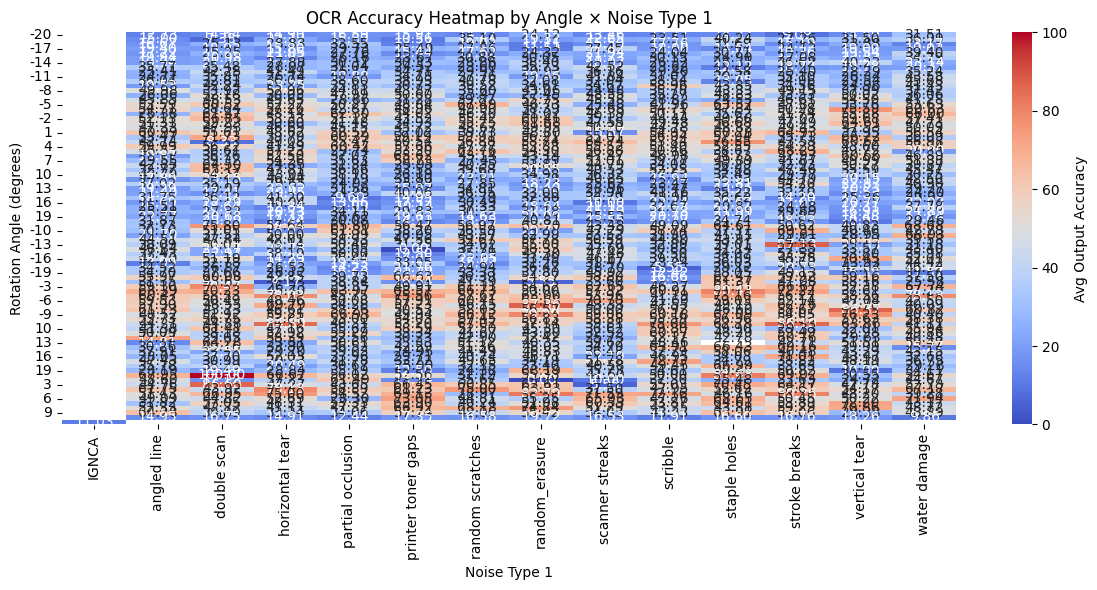

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute average output accuracy across engines
df['avg_output_acc'] = df[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean(axis=1)

# Create pivot table: rows = angle, columns = noise_type1_y
heatmap_data = df.pivot_table(
    index='angle',
    columns='noise_type1',   # You can switch to noise_type2_y or noise_type3_y
    values='avg_output_acc',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Avg Output Accuracy'})

plt.title('OCR Accuracy Heatmap by Angle × Noise Type 1')
plt.xlabel('Noise Type 1')
plt.ylabel('Rotation Angle (degrees)')
plt.tight_layout()
plt.show()


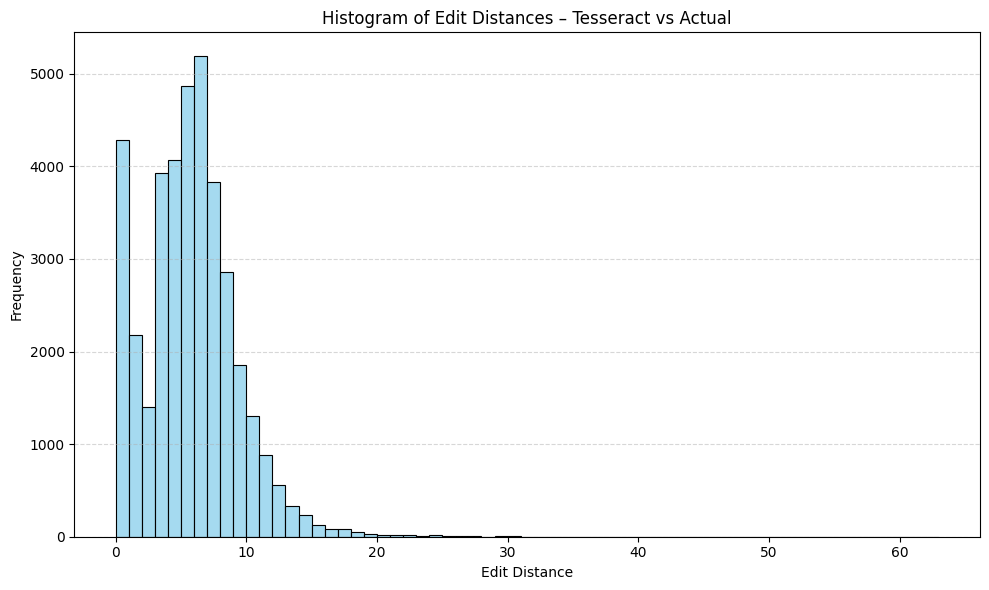

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import editdistance  # pip install editdistance

# Calculate edit distance between Tesseract output and actual word
df['edit_dist_tesseract'] = df.apply(lambda row: editdistance.eval(str(row['tesseract_output']), str(row['word'])), axis=1)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['edit_dist_tesseract'], bins=range(0, df['edit_dist_tesseract'].max()+2), color='skyblue')

plt.title('Histogram of Edit Distances – Tesseract vs Actual')
plt.xlabel('Edit Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This should be bar chart

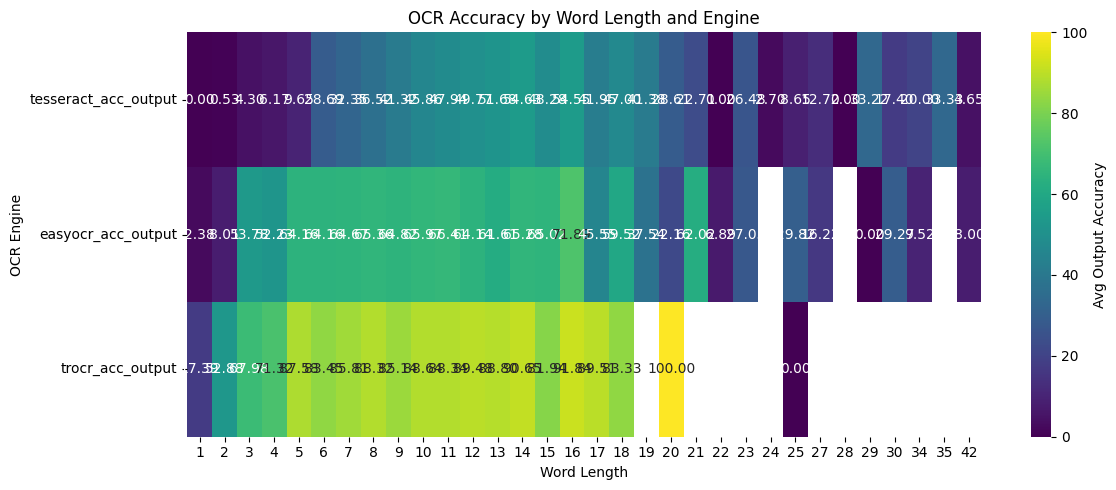

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute word length
df['word_len'] = df['word'].astype(str).apply(len)

# Group by word length and calculate mean accuracy per engine
length_acc = df.groupby('word_len')[[
    'tesseract_acc_output',
    'easyocr_acc_output',
    'trocr_acc_output'
]].mean().T  # Transpose for heatmap layout

# Plot heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(length_acc, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Avg Output Accuracy'})

plt.title('OCR Accuracy by Word Length and Engine')
plt.xlabel('Word Length')
plt.ylabel('OCR Engine')
plt.tight_layout()
plt.show()


2 noise or 3 noise

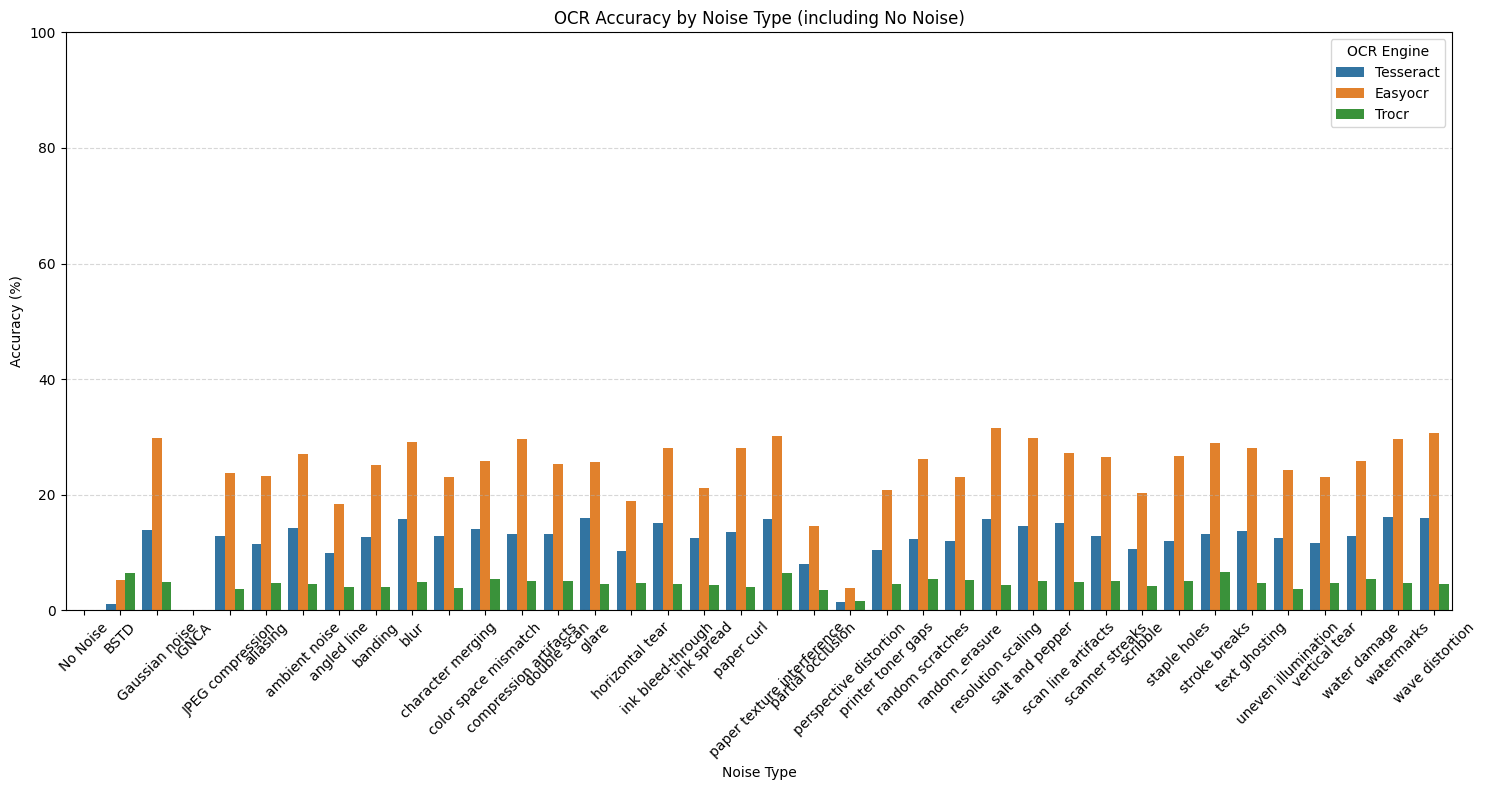

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fill NaNs with empty string for safety
df[['noise_type1', 'noise_type2', 'noise_type3']] = df[
    ['noise_type1', 'noise_type2', 'noise_type3']
].fillna("")

# List to collect results
results = []

# ✅ Step 1: Add clean (no noise) accuracy
clean_mask = (df['noise_type1'] == '') & (df['noise_type2'] == '') & (df['noise_type3'] == '')
df_clean = df[clean_mask]
total_clean = len(df_clean)

if total_clean > 0:
    for engine in ['tesseract', 'easyocr', 'trocr']:
        correct = (df_clean['word'] == df_clean[f'{engine}_output']).sum()
        acc = round(100 * correct / total_clean, 2)
        results.append({
            "Noise Type": "No Noise",
            "OCR Engine": engine.capitalize(),
            "Accuracy (%)": acc
        })

# ✅ Step 2: Get all unique noise types
all_noises = set(df['noise_type1'].unique()) | \
             set(df['noise_type2'].unique()) | \
             set(df['noise_type3'].unique())

all_noises = [n for n in all_noises if n.strip() != '']

# ✅ Step 3: Loop through each noise type
for noise in all_noises:
    mask = (
        (df['noise_type1'] == noise) |
        (df['noise_type2'] == noise) |
        (df['noise_type3'] == noise)
    )
    df_filtered = df[mask]
    total = len(df_filtered)
    if total == 0:
        continue

    for engine in ['tesseract', 'easyocr', 'trocr']:
        correct = (df_filtered['word'] == df_filtered[f'{engine}_output']).sum()
        acc = round(100 * correct / total, 2)
        results.append({
            "Noise Type": noise,
            "OCR Engine": engine.capitalize(),
            "Accuracy (%)": acc
        })

# ✅ Step 4: Convert to DataFrame
acc_df = pd.DataFrame(results)

# Optional: sort "No Noise" first
acc_df["Noise Type"] = pd.Categorical(
    acc_df["Noise Type"],
    categories=["No Noise"] + sorted(set(acc_df["Noise Type"]) - {"No Noise"}),
    ordered=True
)

# ✅ Step 5: Plot
plt.figure(figsize=(15, 8))
sns.barplot(data=acc_df, x="Noise Type", y="Accuracy (%)", hue="OCR Engine")
plt.title("OCR Accuracy by Noise Type (including No Noise)")
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.legend(title="OCR Engine")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


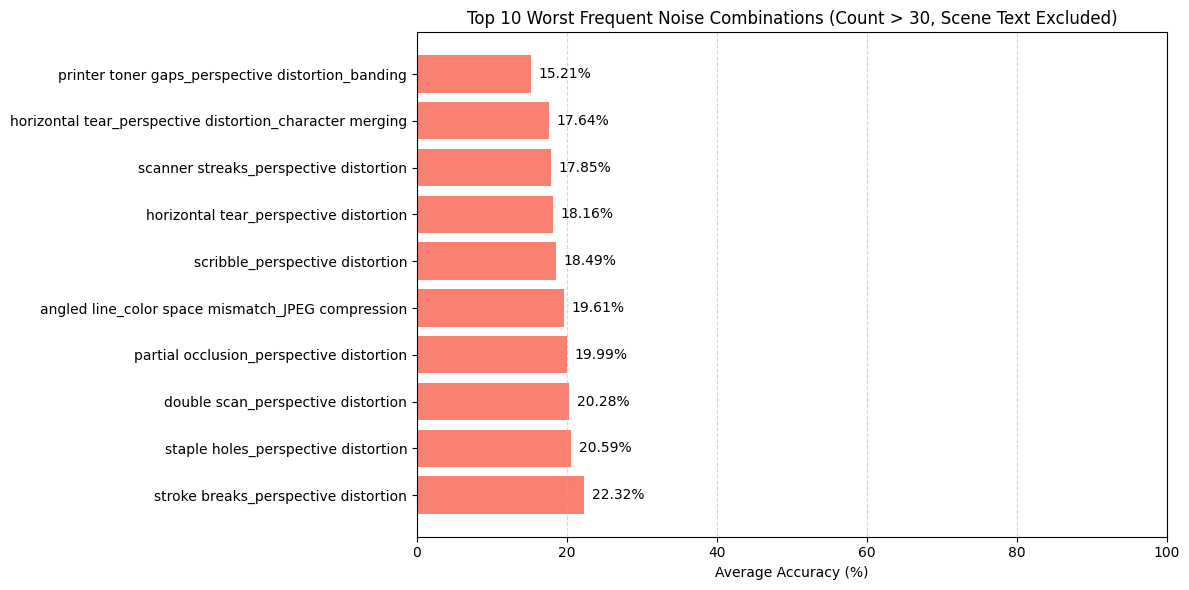

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# ✅ Step 0: Filter out "Scene Text image"
df_filtered = df[df['word_type'].str.lower() != 'scene text image'].copy()

# ✅ Step 1: Create a clean noise combo string
df_filtered['noise_combo'] = df_filtered[['noise_type1', 'noise_type2', 'noise_type3']].fillna('').agg('_'.join, axis=1)
df_filtered['noise_combo'] = df_filtered['noise_combo'].str.replace('_+', '_', regex=True).str.strip('_')
df_filtered['noise_combo'] = df_filtered['noise_combo'].replace('', 'None')

# ✅ Step 2: Calculate average OCR output accuracy
df_filtered['avg_acc_output'] = df_filtered[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean(axis=1)

# Convert to % if needed
if df_filtered['avg_acc_output'].max() <= 1:
    df_filtered['avg_acc_output'] *= 100

# ✅ Step 3: Filter combos that appear more than 30 times
combo_counts = df_filtered['noise_combo'].value_counts().reset_index()
combo_counts.columns = ['noise_combo', 'count']
combo_counts = combo_counts[combo_counts['count'] > 10]

# ✅ Step 4: Get average accuracy for these combos
combo_acc = df_filtered.groupby('noise_combo')['avg_acc_output'].mean().reset_index()

# ✅ Merge to keep only frequent combos
combo_merged = pd.merge(combo_counts, combo_acc, on='noise_combo')

# ✅ Remove very high accuracy ones (optional)
combo_merged = combo_merged[combo_merged['avg_acc_output'] > 5]

# ✅ Step 5: Sort to get 10 worst combos
top10 = combo_merged.sort_values('avg_acc_output').head(10)

# ✅ Step 6: Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['noise_combo'], top10['avg_acc_output'], color='salmon')
plt.xlabel('Average Accuracy (%)')
plt.title('Top 10 Worst Frequent Noise Combinations (Count > 30, Scene Text Excluded)')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center')

plt.tight_layout()
plt.show()


In [54]:
df[df['noise_type1']=='horizontal tear'][df['noise_type2']=='perspective distortion'][df['noise_type3']=='salt and pepper']

/tmp/ipython-input-54-1489368097.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['noise_type1']=='horizontal tear'][df['noise_type2']=='perspective distortion'][df['noise_type3']=='salt and pepper']
/tmp/ipython-input-54-1489368097.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['noise_type1']=='horizontal tear'][df['noise_type2']=='perspective distortion'][df['noise_type3']=='salt and pepper']


,code,word,language,word_type,text_color,background_color,font_size,font_family,font_style,font_path,...,tesseract_drop,easyocr_drop,trocr_drop,avg_drop,avg_acc_noisy,avg_acc_output,word_length,edit_dist_tesseract,word_len,noise_combination
11485,1236,bearings,English,lower,aliceblue,darkred,58,Allura,Regular,/DATA1/ocrteam/word_restoration/reconstruction...,...,0.0,87.5,33.33,40.276667,22.223333,16.943333,8,8,8,1+2+3
24979,730,குடியரசு,Tamil,normal,saddlebrown,lavender,114,Coiny,Regular,/DATA1/ocrteam/word_restoration/reconstruction...,...,25.0,0.0,NaN,12.500000,0.000000,0.000000,8,8,8,1+2+3
25107,858,பரபரப்பு,Tamil,normal,darkgreen,lightgray,64,Coiny,Regular,/DATA1/ocrteam/word_restoration/reconstruction...,...,0.0,0.0,NaN,0.000000,0.000000,0.000000,8,8,8,1+2+3
29183,934,नामान्तरमस्ति,Sanskrit,normal,lightcyan,steelblue,104,Playpen_Sans_Deva,Light,/DATA1/ocrteam/word_restoration/reconstruction...,...,100.0,NaN,NaN,100.000000,0.000000,0.000000,13,13,13,1+2+3


In [55]:
worst_combos = combo_acc.sort_values(by='avg_acc_output').head(10)
worst_combos

,noise_combo,avg_acc_output
1577,water damage_perspective distortion_banding,0.0
668,random scratches_ink bleed-through_ink spread,0.0
692,random scratches_perspective distortion_banding,0.0
1540,water damage_color space mismatch_uneven illum...,0.0
952,scanner streaks_perspective distortion_uneven ...,0.0
1473,vertical tear_resolution scaling_uneven illumi...,0.0
1367,stroke breaks_watermarks_ambient noise,0.0
442,partial occlusion_perspective distortion_compr...,0.0
1028,scribble_color space mismatch_glare,0.0
218,double scan_text ghosting_compression artifacts,0.0


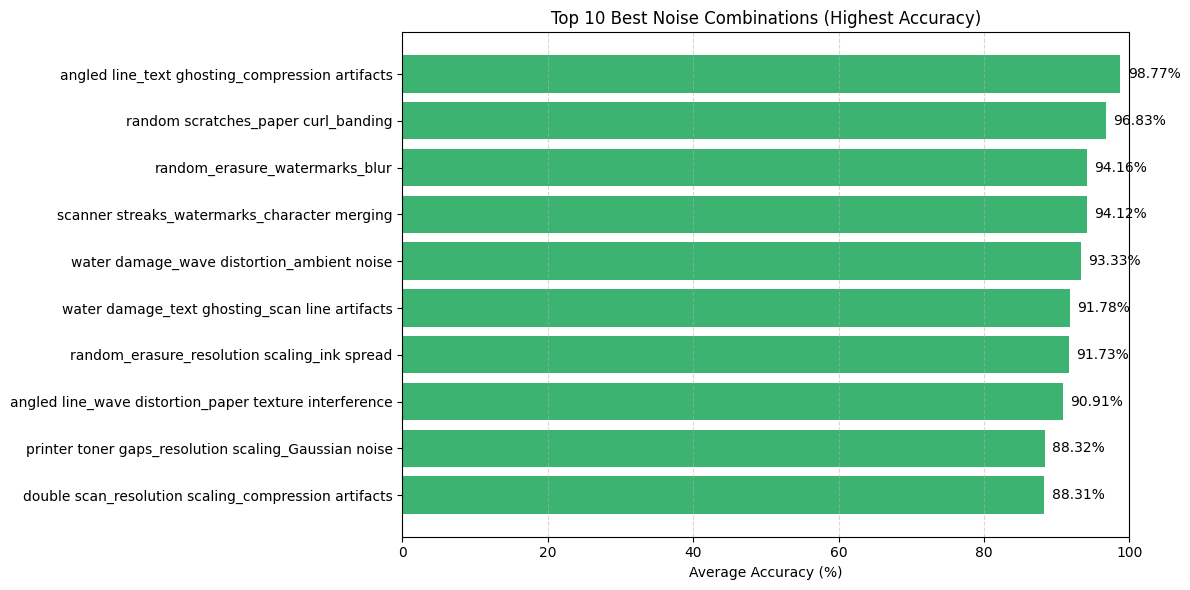

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Create noise combination string
df['noise_combo'] = df[['noise_type1', 'noise_type2', 'noise_type3']].fillna('').agg('_'.join, axis=1)
df['noise_combo'] = df['noise_combo'].str.replace('_+', '_', regex=True).str.strip('_')
df['noise_combo'] = df['noise_combo'].replace('', 'None')

# Step 2: Compute average OCR output accuracy
df['avg_acc_output'] = df[['tesseract_acc_output', 'easyocr_acc_output']].mean(axis=1)

# Convert to percentage if needed
if df['avg_acc_output'].max() <= 1:
    df['avg_acc_output'] *= 100

# Step 3: Group by noise combo and average
combo_acc = df.groupby('noise_combo')['avg_acc_output'].mean().reset_index()

# Remove combos with exactly 0 accuracy
combo_acc = combo_acc[combo_acc['avg_acc_output'] < 100]

# Step 4: Get top 10 best combos
top10_max = combo_acc.sort_values('avg_acc_output', ascending=False).head(10)

# Step 5: Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(top10_max['noise_combo'], top10_max['avg_acc_output'], color='mediumseagreen')
plt.xlabel('Average Accuracy (%)')
plt.title('Top 10 Best Noise Combinations (Highest Accuracy)')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center')

plt.tight_layout()
plt.show()


In [57]:
combo_acc = combo_acc[combo_acc['avg_acc_output'] ]

KeyError: "None of [Index([11.025120000000001,  45.24386861313869, 13.426381322957198,\n       49.420227272727274,  45.97201492537314, 42.752769230769225,\n        48.05291666666667, 45.684821428571425, 53.256403508771925,\n                 41.58775,\n       ...\n                   93.333,           32.91625,          54.545625,\n        47.00277777777777,             66.175,           60.71375,\n                  69.4675,            18.6675,            86.1125,\n        70.96722222222223],\n      dtype='float64', length=1654)] are in the [columns]"

In [58]:
combo_acc

,noise_combo,avg_acc_output
0,IGNCA_IGNCA_IGNCA,11.025120
1,angled line,45.243869
2,angled line_BSTD_BSTD,13.426381
3,angled line_Gaussian noise,49.420227
4,angled line_JPEG compression,45.972015
...,...,...
1653,water damage_wave distortion_glare,60.713750
1654,water damage_wave distortion_ink spread,69.467500
1655,water damage_wave distortion_paper texture int...,18.667500
1657,water damage_wave distortion_scan line artifacts,86.112500


In [59]:
import pandas as pd

# Group by language and calculate mean accuracy for all OCR engine types
lang_acc = df.groupby('language')[[
    'tesseract_acc_clean', 'tesseract_acc_noisy', 'tesseract_acc_output',
    'easyocr_acc_clean', 'easyocr_acc_noisy', 'easyocr_acc_output',
    'trocr_acc_clean', 'trocr_acc_noisy', 'trocr_acc_output'
]].mean().reset_index()

# Rename columns for better readability
lang_acc.columns = [
    'Language',
    'Tesseract Clean', 'Tesseract Noisy', 'Tesseract Output',
    'EasyOCR Clean', 'EasyOCR Noisy', 'EasyOCR Output',
    'TrOCR Clean', 'TrOCR Noisy', 'TrOCR Output'
]

# Display or export
print(lang_acc)
# Optional: lang_acc.to_csv("ocr_accuracy_by_language.csv", index=False)


     Language  Tesseract Clean  Tesseract Noisy  Tesseract Output  \
0      Arabic        33.196425        13.237795         14.111955   
1     Bengali         9.082150         5.442190          6.596487   
2     Chinese        19.628770         6.945385          9.990215   
3     English        43.796770        20.990677         39.178463   
4      French        65.784590        30.523155         56.895350   
5      German        66.987425        27.384175         57.033170   
6    Gujarati        42.093717        16.033821         23.876420   
7       Hindi        35.997410        14.394527         21.372747   
8    Japanese        38.622755        15.441540         30.743225   
9   Malayalam        50.384164        20.998079         38.786677   
10    Marathi        34.298417        14.753733         25.241807   
11    Punjabi         4.357870         3.498397          2.839370   
12   Sanskrit        40.148820        17.699460         27.669413   
13      Tamil        60.094974    

In [ ]:
filtered_df

,code,word,language,word_type,text_color,background_color,font_size,font_family,font_style,font_path,...,avg_output_acc,tesseract_drop,easyocr_drop,trocr_drop,avg_drop,word_length,edit_dist_tesseract,noise_combination,avg_acc_output,noise_combo
0,2000,JUBILEE,English,Scene Text image,BSTD,BSTD,BSTD,BSTD,BSTD,BSTD,...,20.940000,0.00,18.18,0.00,6.060000,7,7,1+2+3,8.335,scanner streaks_BSTD_BSTD
1,2001,FUNCTION,English,Scene Text image,BSTD,BSTD,BSTD,BSTD,BSTD,BSTD,...,62.500000,0.00,48.21,0.00,16.070000,8,8,1+2+3,43.750,random_erasure_BSTD_BSTD
2,2002,OF,English,Scene Text image,BSTD,BSTD,BSTD,BSTD,BSTD,BSTD,...,50.000000,0.00,-13.33,0.00,-4.443333,2,3,1+2+3,25.000,double scan_BSTD_BSTD
3,2003,20,English,Scene Text image,BSTD,BSTD,BSTD,BSTD,BSTD,BSTD,...,66.666667,66.67,100.00,100.00,88.890000,2,3,1+2+3,50.000,angled line_BSTD_BSTD
4,2004,Disp,English,Scene Text image,BSTD,BSTD,BSTD,BSTD,BSTD,BSTD,...,25.923333,0.00,21.43,-34.92,-4.496667,4,4,1+2+3,16.665,partial occlusion_BSTD_BSTD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36885,636,બલુચિસ્તાનના,Gujarati,normal,dimgray,lightblue,89,Baloo_Bhai_2,ExtraBold,/DATA1/ocrteam/word_restoration/reconstruction...,...,100.000000,0.00,NaN,NaN,0.000000,12,0,1+2+3,100.000,partial occlusion_color space mismatch_blur
36886,637,પુસ્તકનું,Gujarati,normal,seashell,darkcyan,40,Shrikhand,Regular,/DATA1/ocrteam/word_restoration/reconstruction...,...,0.000000,1.31,NaN,NaN,1.310000,9,9,1+2,0.000,random_erasure_resolution scaling
36887,638,ફાધર,Gujarati,normal,brown,mintcream,51,Mukta_Vaani,ExtraBold,/DATA1/ocrteam/word_restoration/reconstruction...,...,0.000000,100.00,NaN,NaN,100.000000,4,4,1+2+3,0.000,printer toner gaps_ink bleed-through_uneven il...
36888,639,અનુકરણ,Gujarati,normal,mistyrose,dimgray,109,Baloo_Bhai_2,Regular,/DATA1/ocrteam/word_restoration/reconstruction...,...,100.000000,100.00,NaN,NaN,100.000000,6,0,1+3,100.000,staple holes_scan line artifacts


In [ ]:
import pandas as pd
from tabulate import tabulate  # pip install tabulate if needed

# Step 1: Filter out 'Scene Text image'
filtered_df = df[~df['word_type'].isin(['Scene Text image'])]

# Step 2: Group by language and calculate average accuracy
lang_acc_filtered = filtered_df.groupby('language')[[
    'tesseract_acc_clean', 'tesseract_acc_noisy', 'tesseract_acc_output',
    'easyocr_acc_clean', 'easyocr_acc_noisy', 'easyocr_acc_output',
    'trocr_acc_clean', 'trocr_acc_noisy', 'trocr_acc_output'
]].mean().reset_index()

# Step 3: Rename columns for clarity
lang_acc_filtered.columns = [
    'Language',
    'Tesseract Clean', 'Tesseract Noisy', 'Tesseract Output',
    'EasyOCR Clean', 'EasyOCR Noisy', 'EasyOCR Output',
    'TrOCR Clean', 'TrOCR Noisy', 'TrOCR Output'
]

# Step 4: Format and print as Markdown table
print(tabulate(lang_acc_filtered, headers='keys', tablefmt='github', floatfmt=".2f"))

# Optional: To save the table to a CSV
# lang_acc_filtered.to_csv("filtered_ocr_accuracy_summary.csv", index=False)


|    | Language   |   Tesseract Clean |   Tesseract Noisy |   Tesseract Output |   EasyOCR Clean |   EasyOCR Noisy |   EasyOCR Output |   TrOCR Clean |   TrOCR Noisy |   TrOCR Output |
|----|------------|-------------------|-------------------|--------------------|-----------------|-----------------|------------------|---------------|---------------|----------------|
|  0 | Arabic     |              0.26 |              0.05 |               0.04 |            0.81 |            0.32 |             0.39 |          0.00 |          0.00 |           0.00 |
|  1 | Bengali    |              0.06 |              0.02 |               0.02 |            0.69 |            0.30 |             0.38 |          0.00 |          0.00 |           0.00 |
|  2 | Chinese    |              0.10 |              0.02 |               0.03 |            0.78 |            0.27 |             0.44 |          0.00 |          0.00 |           0.00 |
|  3 | English    |              0.44 |              0.13 |               0

/tmp/ipython-input-77-523665274.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipython-input-77-523665274.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipython-input-77-523665274.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


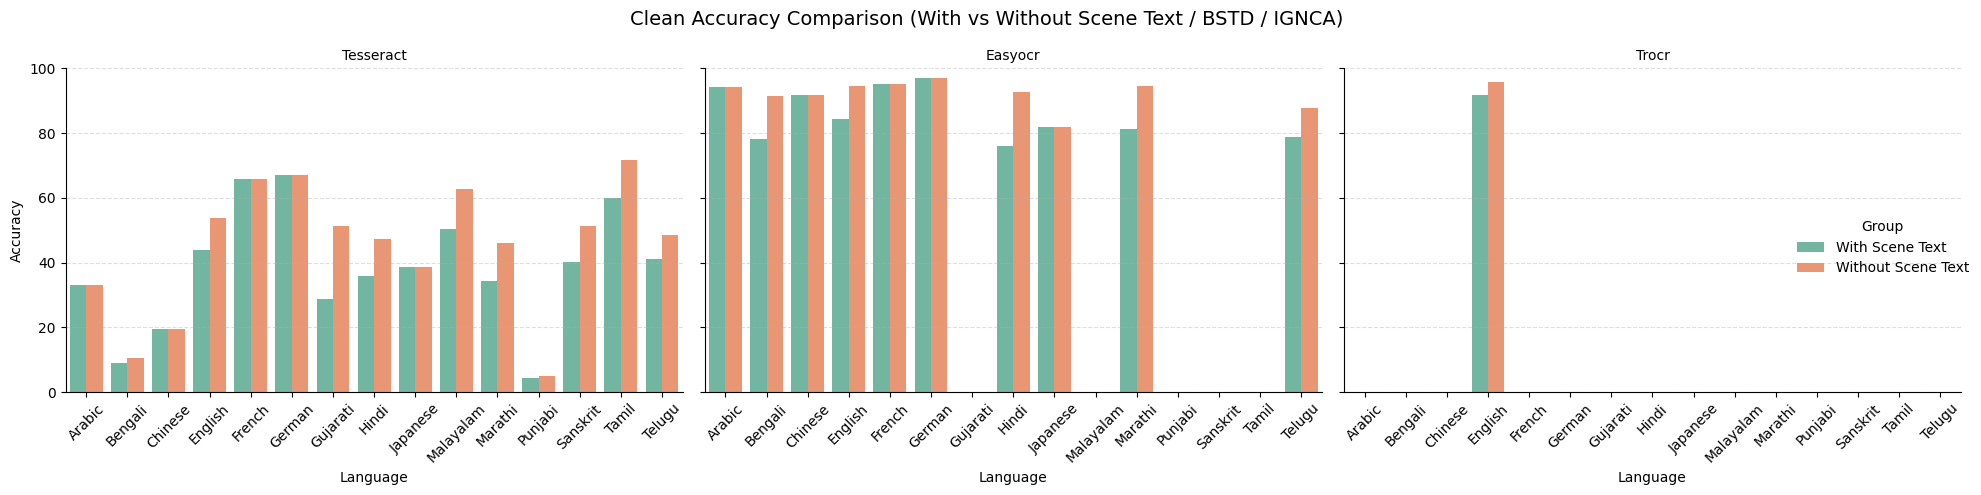

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Accuracy WITH all data
with_all = df.groupby('language')[[
    'tesseract_acc_clean', 'easyocr_acc_clean', 'trocr_acc_clean'
]].mean().reset_index()
with_all['Group'] = 'With Scene Text'

# Step 2: Accuracy WITHOUT scene text / BSTD / IGNCA
filtered_df = df[~df['word_type'].isin(['Scene Text image', 'BSTD', 'IGNCA'])]
without = filtered_df.groupby('language')[[
    'tesseract_acc_clean', 'easyocr_acc_clean', 'trocr_acc_clean'
]].mean().reset_index()
without['Group'] = 'Without Scene Text'

# Step 3: Combine both
combined = pd.concat([with_all, without])
combined_melted = pd.melt(
    combined,
    id_vars=['language', 'Group'],
    value_vars=['tesseract_acc_clean', 'easyocr_acc_clean', 'trocr_acc_clean'],
    var_name='OCR Engine',
    value_name='Accuracy'
)

# Step 4: Clean up engine names
combined_melted['OCR Engine'] = combined_melted['OCR Engine'].str.replace('_acc_clean', '').str.title()

# Step 5: Plot — Faceted barplot per OCR Engine
g = sns.catplot(
    data=combined_melted,
    x='language',
    y='Accuracy',
    hue='Group',
    col='OCR Engine',
    kind='bar',
    height=5,
    aspect=1.2,
    palette='Set2'
)

g.set_titles("{col_name}")
g.set_axis_labels("Language", "Accuracy")
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_ylim(0, 100)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Clean Accuracy Comparison (With vs Without Scene Text / BSTD / IGNCA)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# List of word_types to exclude
excluded_types = ['Scene Text image', 'BSTD', 'IGNCA']

# With all data
avg_with_scene = df[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean()

# Without scene text / BSTD / IGNCA
df_filtered = df[~df['word_type'].isin(excluded_types)]
avg_without_scene = df_filtered[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean()

# Print results
print("🔹 Average Clean Accuracy (WITH Scene Text / BSTD / IGNCA):")
print(avg_with_scene.round(2))
print("\n🔹 Average Clean Accuracy (WITHOUT Scene Text / BSTD / IGNCA):")
print(avg_without_scene.round(2))


🔹 Average Clean Accuracy (WITH Scene Text / BSTD / IGNCA):
tesseract_acc_output    27.71
easyocr_acc_output      62.10
trocr_acc_output        83.10
dtype: float64

🔹 Average Clean Accuracy (WITHOUT Scene Text / BSTD / IGNCA):
tesseract_acc_output    33.71
easyocr_acc_output      69.49
trocr_acc_output        89.99
dtype: float64


In [ ]:
# Count number of rows (samples) per language
language_counts = df.groupby('language').size().reset_index(name='count')

# Sort (optional)
language_counts = language_counts.sort_values(by='count', ascending=False)

print(language_counts)


     language  count
1     Bengali   3000
3     English   3000
7       Hindi   3000
11    Punjabi   3000
12   Sanskrit   3000
10    Marathi   3000
6    Gujarati   2693
9   Malayalam   2567
13      Tamil   2507
14     Telugu   2482
2     Chinese   2000
5      German   2000
4      French   2000
0      Arabic   2000
8    Japanese   2000


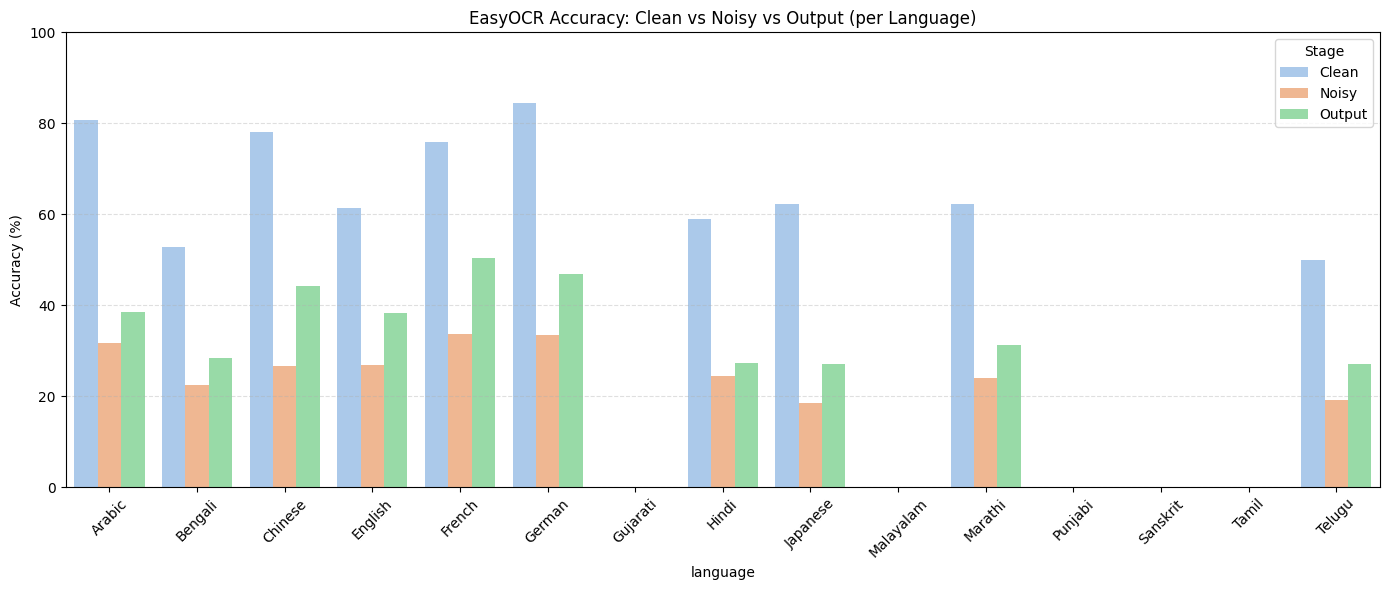

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Compute binary match accuracy for EasyOCR
df['easyocr_acc_clean'] = (df['word'] == df['easyocr_clean']).astype(int)
df['easyocr_acc_noisy'] = (df['word'] == df['easyocr_noisy']).astype(int)
df['easyocr_acc_output'] = (df['word'] == df['easyocr_output']).astype(int)

# Step 2: Group by language and calculate mean accuracy
acc_df = df.groupby('language')[['easyocr_acc_clean', 'easyocr_acc_noisy', 'easyocr_acc_output']].mean() * 100

# Step 3: Prepare data for plotting
plot_df = acc_df.reset_index().melt(id_vars='language',
                                    var_name='Stage',
                                    value_name='Accuracy (%)')
plot_df['Stage'] = plot_df['Stage'].str.replace('easyocr_acc_', '').str.capitalize()

# Step 4: Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='language', y='Accuracy (%)', hue='Stage', palette='pastel')
plt.title('EasyOCR Accuracy: Clean vs Noisy vs Output (per Language)')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Step 1: Compute binary match (1 if OCR output matches GT word)
for ocr in ['tesseract', 'easyocr', 'trocr']:
    df[f'{ocr}_acc_clean'] = (df['word'] == df[f'{ocr}_clean']).astype(int)
    df[f'{ocr}_acc_noisy'] = (df['word'] == df[f'{ocr}_noisy']).astype(int)
    df[f'{ocr}_acc_output'] = (df['word'] == df[f'{ocr}_output']).astype(int)

# Step 2: Group by language and compute mean accuracy
acc_cols = [col for col in df.columns if col.startswith(('tesseract_acc', 'easyocr_acc', 'trocr_acc'))]
acc_df = df.groupby('language')[acc_cols].mean() * 100  # convert to %

# Step 3: Average across engines for clean, noisy, and output
acc_df['Clean Accuracy (%)'] = acc_df[[col for col in acc_df.columns if 'clean' in col]].mean(axis=1).round(2)
acc_df['Noisy Accuracy (%)'] = acc_df[[col for col in acc_df.columns if 'noisy' in col]].mean(axis=1).round(2)
acc_df['Output Accuracy (%)'] = acc_df[[col for col in acc_df.columns if 'output' in col]].mean(axis=1).round(2)

# Step 4: Prepare final output table
final_table = acc_df[['Clean Accuracy (%)', 'Noisy Accuracy (%)', 'Output Accuracy (%)']].reset_index()

# Optional: Sort by Clean Accuracy or Language
final_table = final_table.sort_values(by='language').reset_index(drop=True)

# Display
print(final_table.to_markdown(index=False))


| language   |   Clean Accuracy (%) |   Noisy Accuracy (%) |   Output Accuracy (%) |
|:-----------|---------------------:|---------------------:|----------------------:|
| Arabic     |                35.45 |                12.3  |                 14.07 |
| Bengali    |                19.1  |                 7.96 |                  9.94 |
| Chinese    |                29.33 |                 9.62 |                 15.78 |
| English    |                56.98 |                27.86 |                 41.09 |
| French     |                42.72 |                16.25 |                 29.42 |
| German     |                46.22 |                15.73 |                 27.52 |
| Gujarati   |                 9.64 |                 2.15 |                  3.04 |
| Hindi      |                28.01 |                10.34 |                 11.34 |
| Japanese   |                26.9  |                 7.37 |                 11.57 |
| Malayalam  |                 5.26 |                 1.27 |     

/tmp/ipython-input-23-4021447352.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_df, x='OCR Engine & Type', y='Accuracy', palette='Set2')


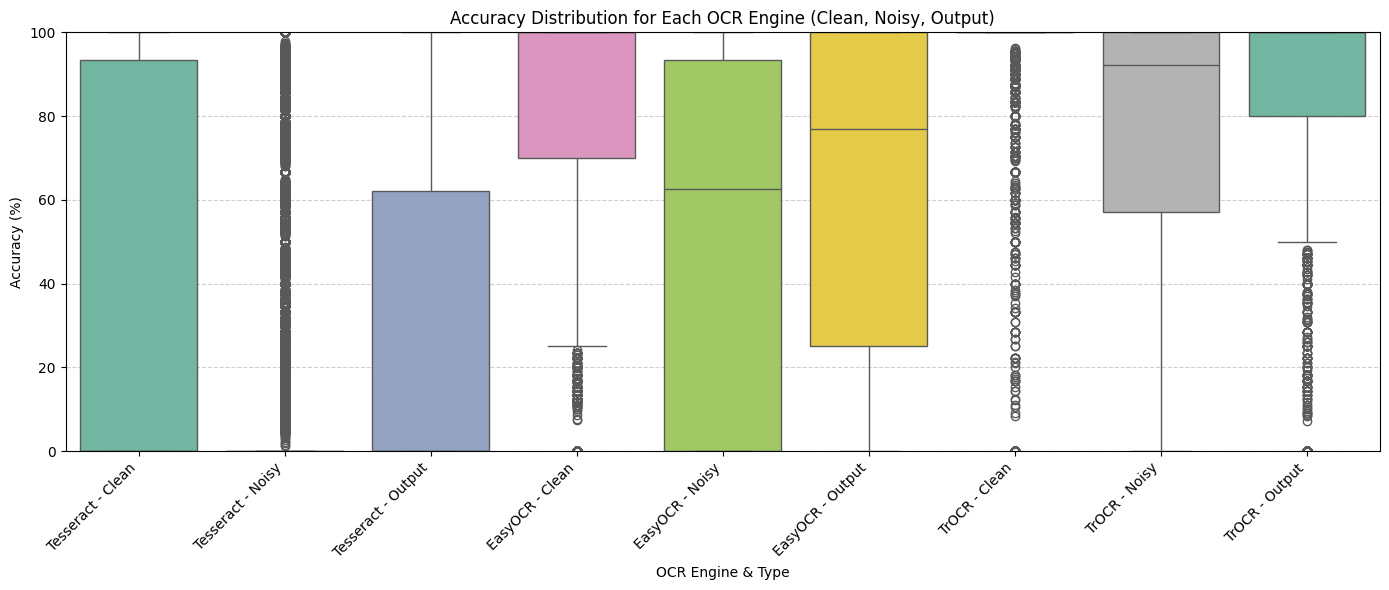

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data in long format for boxplot
boxplot_data = pd.DataFrame({
    'Tesseract - Clean': df['tesseract_acc_clean'],
    'Tesseract - Noisy': df['tesseract_acc_noisy'],
    'Tesseract - Output': df['tesseract_acc_output'],
    'EasyOCR - Clean': df['easyocr_acc_clean'],
    'EasyOCR - Noisy': df['easyocr_acc_noisy'],
    'EasyOCR - Output': df['easyocr_acc_output'],
    'TrOCR - Clean': df['trocr_acc_clean'],
    'TrOCR - Noisy': df['trocr_acc_noisy'],
    'TrOCR - Output': df['trocr_acc_output'],
})

# Melt the DataFrame for seaborn boxplot
melted_df = boxplot_data.melt(var_name='OCR Engine & Type', value_name='Accuracy')

# Create the boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=melted_df, x='OCR Engine & Type', y='Accuracy', palette='Set2')

# Rotate x labels and style plot
plt.xticks(rotation=45, ha='right')
plt.title('Accuracy Distribution for Each OCR Engine (Clean, Noisy, Output)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Because your values are in percentage
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/ocr_test4_data.csv')
# Select only the accuracy columns and language
acc_columns = [
    'tesseract_acc_output',
     'easyocr_acc_output', 'trocr_acc_output'
]

# Group by language and take mean
acc_summary = df.groupby('language')[acc_columns].mean().round(4)  # % accuracy

# Reset index for clean display
acc_summary = acc_summary.reset_index()
print(acc_summary)
# Optional: Display table
print(acc_summary.to_markdown(index=False))

     language  tesseract_acc_output  easyocr_acc_output  trocr_acc_output
0      Arabic               14.1120             76.0253               NaN
1     Bengali                6.5965             64.7128               NaN
2     Chinese                9.9902             71.3265               NaN
3     English               39.1785             70.4695           83.0988
4      French               56.8954             82.4000               NaN
5      German               57.0332             79.4202               NaN
6    Gujarati               23.8764                 NaN               NaN
7       Hindi               21.3727             58.4974               NaN
8    Japanese               30.7432             63.3950               NaN
9   Malayalam               38.7867                 NaN               NaN
10    Marathi               25.2418             63.2662               NaN
11    Punjabi                2.8394                 NaN               NaN
12   Sanskrit               27.6694   

/tmp/ipython-input-9-4265120873.py:2: DtypeWarning: Columns (6,13,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/ocr_test4_data.csv')


/tmp/ipython-input-24-31206782.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted_violin, x='OCR Engine & Type', y='Accuracy', palette='Set3', inner='box')


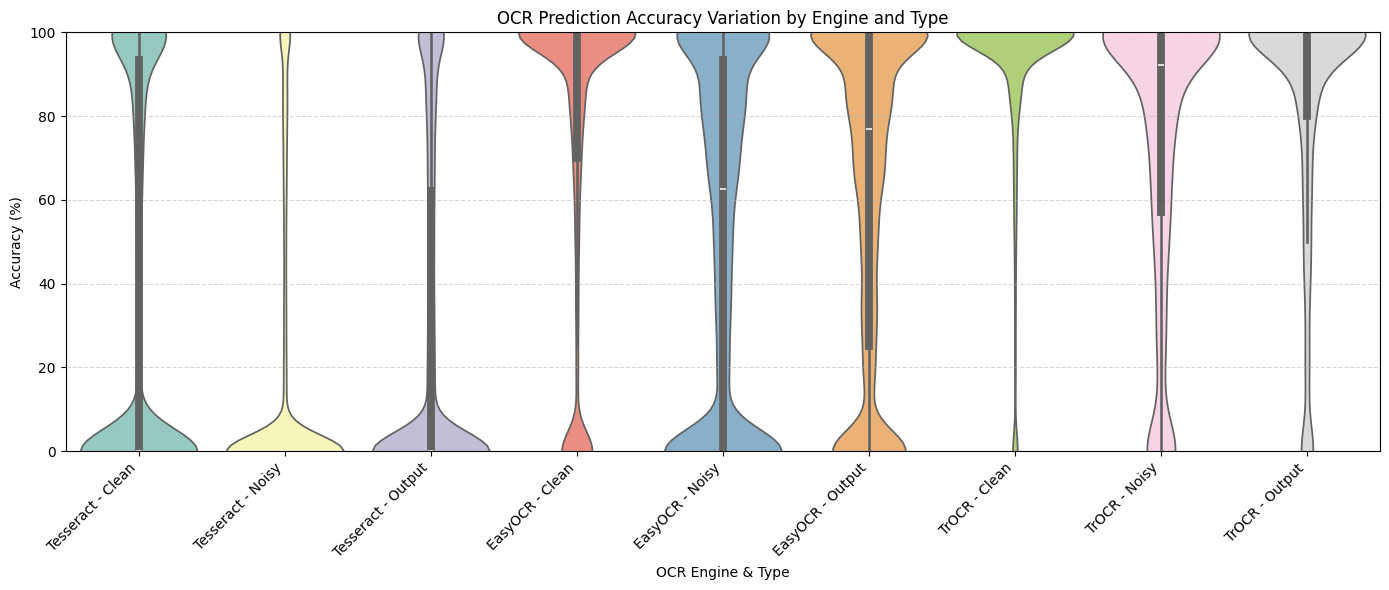

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data in long format
violin_data = pd.DataFrame({
    'Tesseract - Clean': df['tesseract_acc_clean'],
    'Tesseract - Noisy': df['tesseract_acc_noisy'],
    'Tesseract - Output': df['tesseract_acc_output'],
    'EasyOCR - Clean': df['easyocr_acc_clean'],
    'EasyOCR - Noisy': df['easyocr_acc_noisy'],
    'EasyOCR - Output': df['easyocr_acc_output'],
    'TrOCR - Clean': df['trocr_acc_clean'],
    'TrOCR - Noisy': df['trocr_acc_noisy'],
    'TrOCR - Output': df['trocr_acc_output'],
})

# Melt for seaborn violin plot
melted_violin = violin_data.melt(var_name='OCR Engine & Type', value_name='Accuracy')

# Plot violin plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=melted_violin, x='OCR Engine & Type', y='Accuracy', palette='Set3', inner='box')

# Styling
plt.title('OCR Prediction Accuracy Variation by Engine and Type')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # Adjusted for percentage values
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
df['word']

,word
0,JUBILEE
1,FUNCTION
2,OF
3,20
4,Disp
...,...
38244,લૈલા
38245,ગુણકારી
38246,ડબ્બો
38247,૧૦૦ની


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from collections import Counter
import numpy as np

# Example: Load from Excel with columns: 'image_name', 'ground_truth', 'tesseract_output'
df = pd.read_csv("/content/ocr_test4_data.csv")




/tmp/ipython-input-16-3143282362.py:9: DtypeWarning: Columns (6,13,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/ocr_test4_data.csv")


In [ ]:
df.columns

Index(['code', 'word', 'language', 'word_type', 'text_color',
       'background_color', 'font_size', 'font_family', 'font_style',
       'font_path', 'noise_type1', 'noise_type2', 'noise_type3', 'angle',
       'clean_path', 'noisy_path', 'binary_mask_path', 'ISM_mask_path',
       'CSM_mask_path', 'tesseract_clean', 'tesseract_noisy',
       'tesseract_output', 'easyocr_clean', 'easyocr_noisy', 'easyocr_output',
       'trocr_clean', 'trocr_noisy', 'trocr_output', 'tesseract_acc_clean',
       'tesseract_acc_noisy', 'tesseract_acc_output', 'easyocr_acc_clean',
       'easyocr_acc_noisy', 'easyocr_acc_output', 'trocr_acc_clean',
       'trocr_acc_noisy', 'trocr_acc_output', 'output_path'],
      dtype='object')

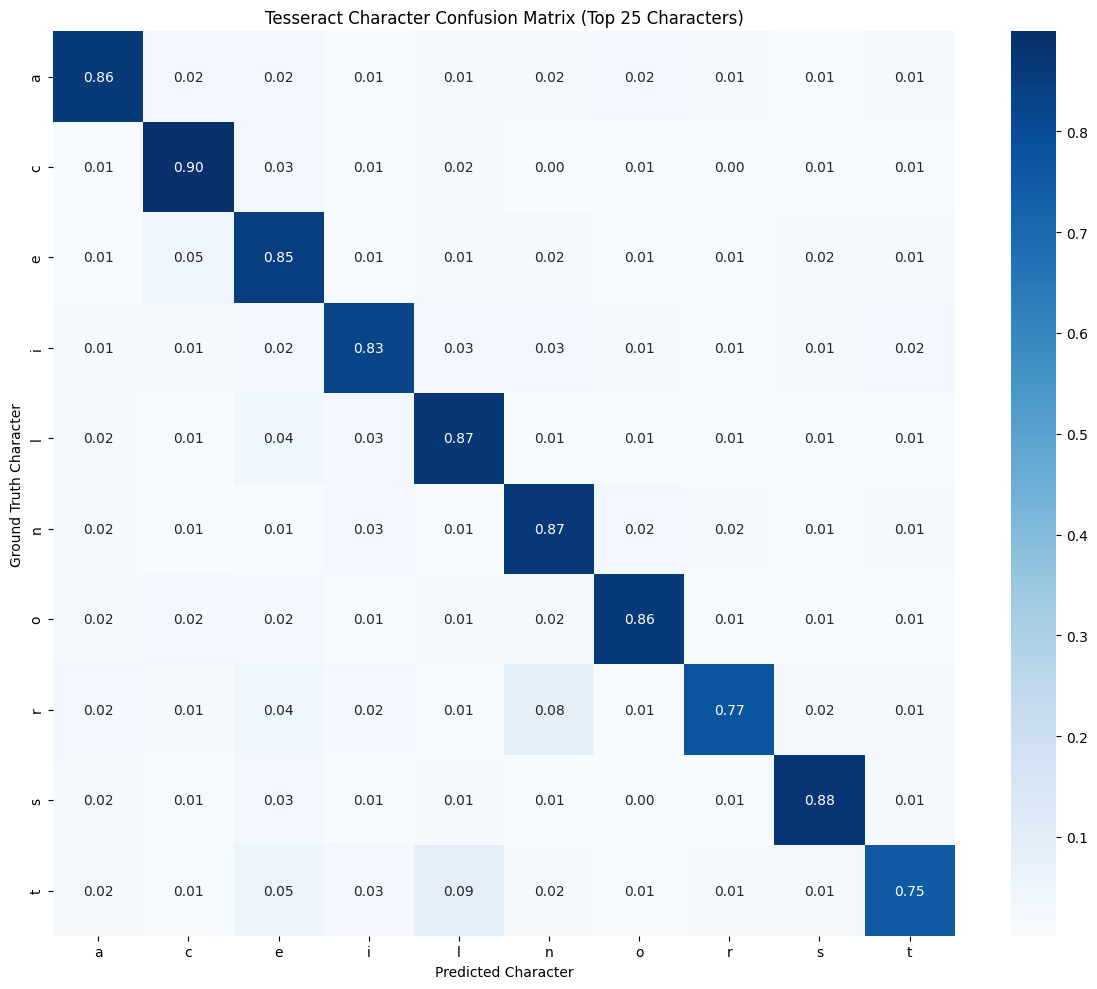

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from collections import Counter
import numpy as np

# or .xlsx with pd.read_excel()
df =df[df['language']=='English']
# Filter out nulls and pick relevant columns
df = df[['word', 'easyocr_output']].dropna()

# Create character-level lists
y_true_chars = []
y_pred_chars = []

for gt, pred in zip(df['word'], df['easyocr_output']):
    min_len = min(len(gt), len(pred))
    y_true_chars.extend(list(gt[:min_len]))
    y_pred_chars.extend(list(pred[:min_len]))

# Get top 25 most frequent ground truth characters
top_chars = [char for char, _ in Counter(y_true_chars).most_common(10)]

# Filter to top characters only (for cleaner matrix)
filtered_true = [c for c, p in zip(y_true_chars, y_pred_chars) if c in top_chars and p in top_chars]
filtered_pred = [p for c, p in zip(y_true_chars, y_pred_chars) if c in top_chars and p in top_chars]

# Compute confusion matrix
labels = sorted(set(top_chars))
cm = confusion_matrix(filtered_true, filtered_pred, labels=labels)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # Normalize row-wise

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Tesseract Character Confusion Matrix (Top 25 Characters)")
plt.xlabel("Predicted Character")
plt.ylabel("Ground Truth Character")
plt.tight_layout()
plt.show()


In [ ]:
import csv

# Set paths
txt_file_path = "/content/label.txt"  # replace with your actual file path
output_csv_path = "output.csv"    # desired output CSV path
base_path = "/DATA1/ocrteam/word_restoration/reconstruction/IC17_test/output_GSDM_Data/"     # base path to append before image code

# Read the text and write to CSV
with open(txt_file_path, "r", encoding="utf-8") as infile, open(output_csv_path, "w", newline='', encoding="utf-8") as outfile:
    writer = csv.writer(outfile)
    writer.writerow(["image_code", "word", "output_path"])

    for line in infile:
        parts = line.strip().split(maxsplit=1)
        if len(parts) == 2:
            image_code, word = parts
            output_path = base_path + image_code
            writer.writerow([image_code, word, output_path])

In [ ]:
import pandas as pd
df = pd.read_csv("/content/output.csv")

In [ ]:
df['output_path2'] = df['output_path'].apply(lambda x: x.replace('/output_GSDM_Data/', '/output_GSDM_our_Data/'))

In [ ]:
df['output_path'][0]

'/DATA1/ocrteam/word_restoration/reconstruction/IC17_test/output_GSDM_Data/0000.png'

In [ ]:
df.to_csv("modified_output.csv", index=False)

/tmp/ipython-input-38-1866595921.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='word_type', y='avg_output_acc', palette='Set2')


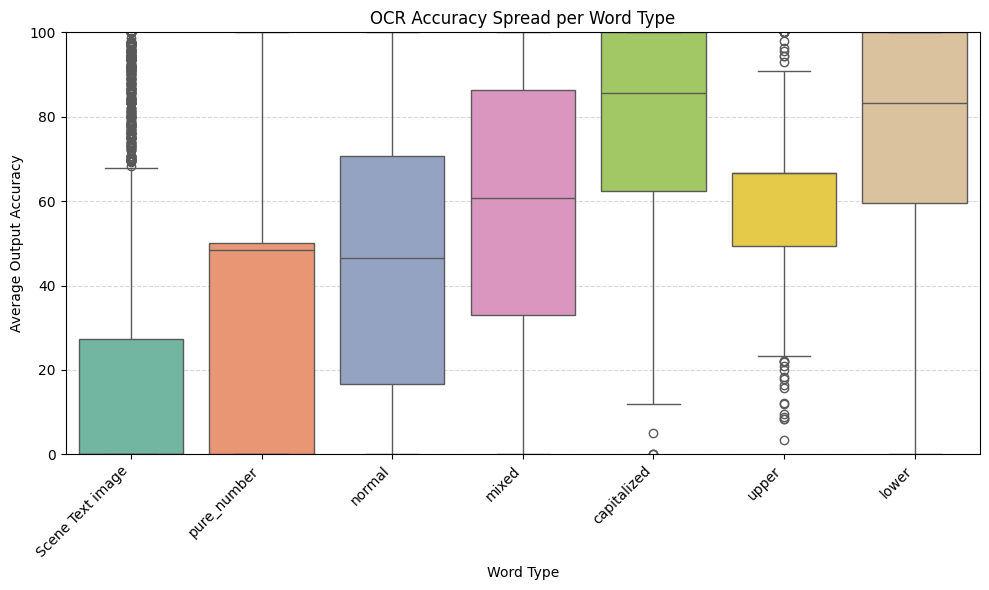

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute average accuracy across engines for each row
df['avg_output_acc'] = df[['tesseract_acc_output', 'easyocr_acc_output', 'trocr_acc_output']].mean(axis=1)

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='word_type', y='avg_output_acc', palette='Set2')

plt.title('OCR Accuracy Spread per Word Type')
plt.xlabel('Word Type')
plt.ylabel('Average Output Accuracy')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
